# 6.3 Bi-Encoders, Cross-Encoders, and RAG -- Interview Preparation Guide

> **Scope:** This notebook covers Bi-encoder and Cross-encoder architectures, Cross-Attention mechanisms, and Retrieval-Augmented Generation (RAG) -- all essential topics for ML/NLP interviews.

---

### **Bi-Encoders vs. Cross-Encoders: Understanding the Concepts**

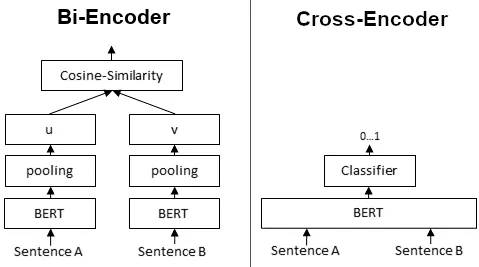



These architectures are primarily used in tasks that involve comparing or finding relationships between **pairs** of inputs (e.g., two sentences, a query and a document, a question and an answer). Common tasks include semantic similarity, information retrieval, question answering, and natural language inference.

**1. Bi-Encoder Architecture**

*   **Core Idea:** Processes the two inputs **independently** using the *same* encoder network (like BERT, RoBERTa, etc., with shared weights). Each input is converted into a fixed-size vector embedding. The relationship between the inputs is then determined by comparing these embeddings using a simple similarity metric.

*   **How it Works:**
    1.  **Input A** -> Encoder Network (e.g., BERT) -> **Embedding A** (Vector `v_A`)
    2.  **Input B** -> Encoder Network (e.g., BERT) -> **Embedding B** (Vector `v_B`)
    3.  **Comparison:** Calculate the similarity between `v_A` and `v_B` using a distance/similarity function (e.g., Cosine Similarity, Dot Product, Euclidean Distance).

*   **Diagrammatic Representation:**
    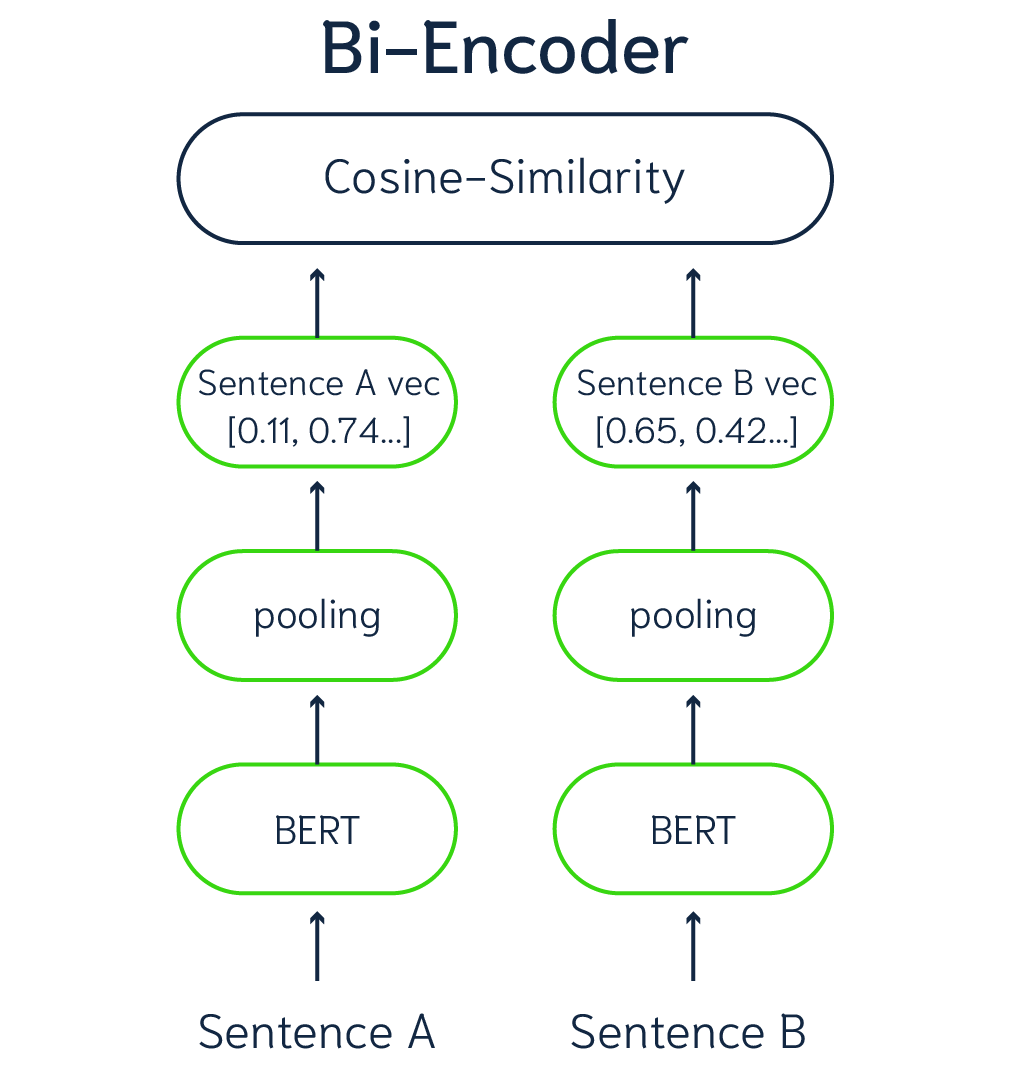

*   **Pros:**
    *   **Extremely Fast Comparison:** Once embeddings are generated, comparing them is computationally very cheap (just a vector operation).
    *   **Scalable for Retrieval:** You can pre-compute embeddings for a large corpus of items (e.g., documents, potential answers) offline. When a new query arrives, you only need to encode the query and then quickly compare its embedding against millions/billions of pre-computed embeddings using efficient vector search libraries (like FAISS, Annoy).

*   **Cons:**
    *   **Less Accurate:** The model never sees the two inputs *together*. It cannot model fine-grained interactions or dependencies between the tokens of Input A and Input B during the encoding process. The final comparison is based solely on the high-level vector representations.

*   **Typical Use Cases:**
    *   Large-scale semantic search / Information Retrieval (finding relevant documents for a query).
    *   Finding similar questions or sentences in a large database.
    *   Candidate generation in multi-stage systems (quickly find a set of potential candidates to be re-ranked later).



**2. Cross-Encoder Architecture**

*   **Core Idea:** Processes the two inputs **simultaneously**. The inputs are concatenated (usually with a special separator token) and fed *together* into a single encoder network. The model learns interactions between the inputs directly through its attention mechanisms. The final output (often from the `[CLS]` token) is used to predict the relationship.

*   **How it Works:**
    1.  **Concatenate Inputs:** Combine Input A and Input B into a single sequence, typically like: `[CLS] Input A [SEP] Input B [SEP]`.
    2.  **Joint Encoding:** Feed this combined sequence through the Encoder Network (e.g., BERT).
    3.  **Prediction:** Take the final hidden state corresponding to the `[CLS]` token (or sometimes pooling over the sequence) and pass it through a classification/regression head to get the final score or label indicating the relationship between Input A and Input B.

*   **Diagrammatic Representation:**
    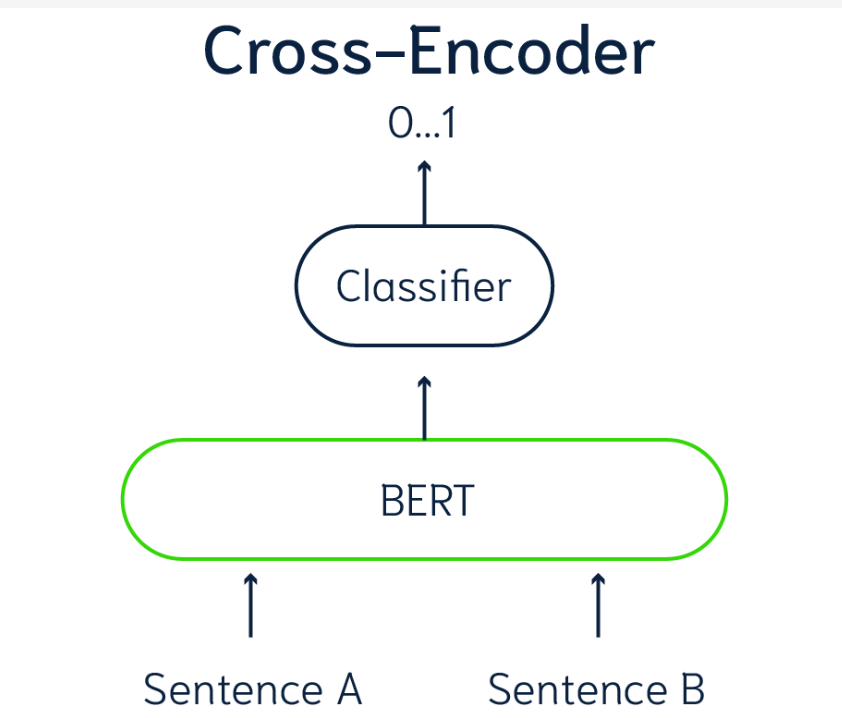


*   **Pros:**
    *   **High Accuracy:** Allows for deep, token-level interaction between Input A and Input B via the self-attention layers of the transformer. Can model complex relationships and nuances effectively. Generally achieves state-of-the-art performance on NLU tasks involving pairs.

*   **Cons:**
    *   **Extremely Slow for Comparison/Retrieval:** Requires passing *every single pair* through the computationally expensive encoder network at inference time. If you need to compare a query to a million documents, you need to run the large encoder a million times. This is often infeasible for large datasets.

*   **Typical Use Cases:**
    *   Re-ranking candidates generated by a Bi-encoder (take the top-k results from the fast Bi-encoder and re-rank them accurately using the slow Cross-encoder).
    *   Natural Language Inference (NLI - determining if a premise entails, contradicts, or is neutral to a hypothesis).
    *   Detailed semantic textual similarity scoring for a small set of pairs.
    *   Answer selection (scoring candidate answers for a question).



**3. Fine-Tuning Techniques**

You need labeled data consisting of pairs (A, B) and a target label indicating their relationship.

*   **Fine-Tuning a Bi-Encoder:**
    *   **Goal:** Train the encoder to produce embeddings where similar pairs are close together in the vector space, and dissimilar pairs are far apart.
    *   **Common Loss Functions:**
        *   **Contrastive Loss:** Requires positive pairs (similar A, B) and negative pairs (dissimilar A, B'). Aims to minimize distance for positive pairs and maximize distance for negative pairs (up to a margin).
        *   **Triplet Loss:** Uses an anchor input (A), a positive input (B - similar to A), and a negative input (C - dissimilar to A). The loss encourages the distance `d(A, B)` to be smaller than `d(A, C)` by at least a margin `m`: `max(0, d(A, B) - d(A, C) + m)`.
        *   **Multiple Negatives Ranking Loss (MNRL):** Highly effective and common for training sentence embeddings (like Sentence-BERT). In a batch, for a given positive pair (A, B), all other B's in the batch are treated as negatives for A. This provides many negatives efficiently. The loss aims to make the similarity score `sim(A, B)` higher than all `sim(A, B_negative)`. Often uses Cross-Entropy over the similarity scores.
    *   **Data Format:** Typically `(input_A, input_B, label)` where label might be 1 for similar, 0 for dissimilar, or you structure it into triplets/anchor-positive-negative sets.

*   **Fine-Tuning a Cross-Encoder:**
    *   **Goal:** Train the model to predict the relationship label/score directly from the concatenated input.
    *   **Common Loss Functions:**
        *   **Classification:** If the task is classification (e.g., NLI with labels: Entailment, Contradiction, Neutral; or Relevance: Relevant/Not Relevant), use **Cross-Entropy Loss** on the output of the prediction head (usually a linear layer on top of the `[CLS]` embedding).
        *   **Regression:** If the task is predicting a continuous similarity score (e.g., Semantic Textual Similarity scores from 1 to 5), use **Mean Squared Error (MSE) Loss** or similar regression losses.
    *   **Data Format:** Typically `(input_A, input_B, target_label_or_score)`.

**4. Important Points to Remember**

*   **Core Trade-off:** Bi-encoders are **fast** but less accurate; Cross-encoders are **accurate** but slow.
*   **Input Processing:** Bi-encoders process inputs **independently**; Cross-encoders process inputs **jointly**.
*   **Output:** Bi-encoders output **embeddings** to be compared later; Cross-encoders directly output a **score/classification**.
*   **Scalability:** Bi-encoders are essential for **large-scale retrieval** due to pre-computable embeddings. Cross-encoders are not suitable for this.
*   **Common Pattern:** A powerful approach is a **two-stage system**:
    1.  Use a Bi-encoder for fast **candidate retrieval** (find top-k potential matches from a large corpus).
    2.  Use a Cross-encoder for accurate **re-ranking** of these top-k candidates.
*   **Fine-tuning Losses:** Remember contrastive/triplet/MNRL losses for Bi-encoders (push/pull embeddings) and standard classification/regression losses for Cross-encoders (predicting the label/score).
*   **Use Case Alignment:** Choose the architecture based on whether you prioritize speed/scalability (Bi-encoder) or accuracy with limited comparisons (Cross-encoder).

- https://dev-kit.io/blog/ai/fine-tuning-cross-encoders-re-ranking
- https://medium.com/@whyamit101/how-to-fine-tune-embedding-models-for-rag-retrieval-augmented-generation-7c5bf08b3c54

- Code:  ./code/reranking_and_augsbert_encoder_training_lalamaindex.ipynb



# 📘 Preparation Guide: **Cross-Attention (Encoder-Decoder Attention)**

---

## ✅ 1. What is Cross-Attention?

Cross-Attention is a specific **attention mechanism** used in **Transformer models** with an **Encoder-Decoder architecture**.

> 🧠 **Core Idea**: It allows the **Decoder** to "look back" at the **Encoder’s output** and decide **which parts of the input are relevant** for generating the next word in the output.

> 🔁 **Also Known As**: Encoder-Decoder Attention

> 🧩 **Easy Analogy**:  
> _Imagine the Decoder is a writer translating a book._  
> _Every time it writes a new sentence (output), it asks the Encoder (the original book reader): “What part of the original book should I refer to for this?”_

---

## 🎯 2. Why is Cross-Attention Needed?

Without Cross-Attention:
- The Decoder can only use what it has generated so far (via Self-Attention).
- It **lacks grounding** in the original input.

With Cross-Attention:
- The Decoder **establishes a connection** between the input and output.
- It aligns each output token with **relevant parts of the input**.

> 🔗 **Key Purpose**:  
> _To map the output generation process to relevant contextual representations from the input sequence._

---

## 🔄 3. How Does Cross-Attention Work? (Step-by-Step with Example)

### 🗣️ Example:
**Translate** →  
- Input: `"Hello, how are you?"` (English)  
- Target: `"Bonjour, comment vas-tu?"` (French)

---

### 🔹 Step-by-Step Breakdown:

| **Stage**        | **Component** | **Operation**                                                                 |
|------------------|---------------|--------------------------------------------------------------------------------|
| **Step 1**        | Encoder       | Processes the input using **Self-Attention**. Generates contextual embeddings. |
| **Step 2**        | Decoder       | Receives the partial output ("Bonjour...") and processes it via Self-Attention. |
| **Step 3**        | Cross-Attention | Decoder attends to **Encoder outputs** to guide the next word prediction.      |


---

### ⚙️ Cross-Attention Internals:

- **Q (Query)** → From the **Decoder's current hidden state**
- **K (Key)** and **V (Value)** → From the **Encoder's output representations**

> 🎯 **Attention Score** = How much the Decoder's Query matches the Encoder’s Keys.  
> ⬇️  
> Weighted sum of Encoder’s Value vectors gives **context vector**  
> ⬇️  
> Used to help Decoder generate the **next word**.

---

## 🧮 Technical View:

```text
Attention(Q, K, V) = softmax(QKᵀ / √dₖ) · V
```

- Q → Decoder  
- K, V → Encoder  
- Output → Used in the Decoder to generate the next token

---



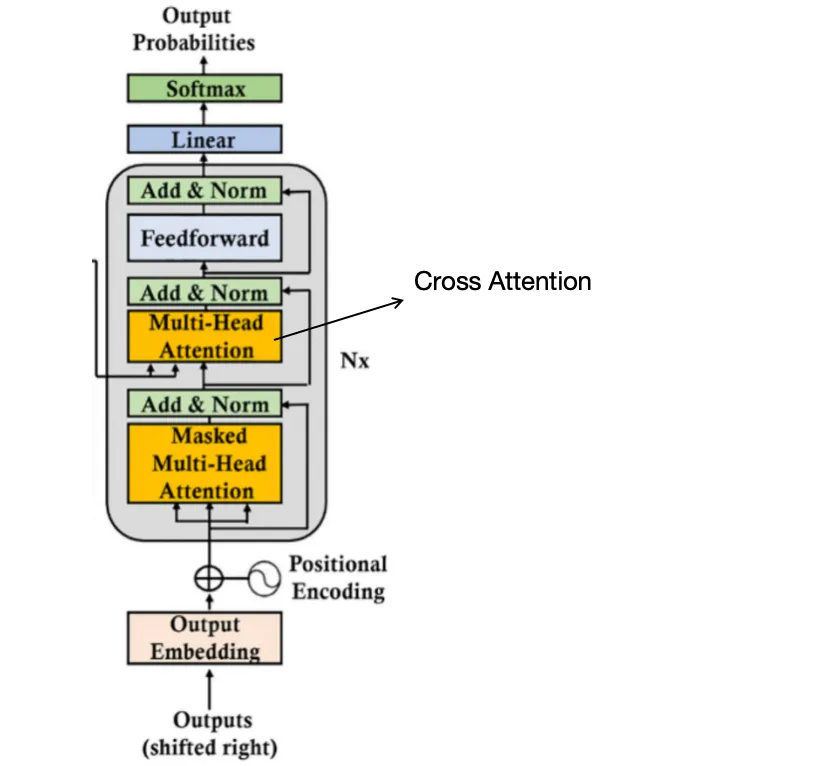
## 🔁 Why Are There Two Attention Layers in the Decoder?

### 1. **Masked Multi-Head Attention (Self-Attention)**
📍 **Where?** The *first* yellow box in the Decoder.

**Purpose**:  
- Helps the Decoder look at **only previous tokens** (not future ones) during training.
- Ensures **auto-regressive generation** — i.e., generating one token at a time.

**Why masked?**  
- During training, we feed in the full output (e.g., "Bonjour, comment..."), but the model must not cheat by looking at future words like "vas-tu".
- The mask ensures attention is only to **tokens to the left (or same position)** — called **causal masking**.

✅ **This helps the model learn to predict the next word** based only on what it has generated so far.

---

### 2. **Multi-Head Attention (Cross-Attention / Encoder-Decoder Attention)**
📍 **Where?** The *second* yellow box labeled “Cross Attention”.

**Purpose**:  
- This is where the Decoder looks at the **Encoder’s outputs**.
- It learns **which parts of the input sequence** (e.g., English sentence) are relevant when generating the current output token.

🔑 **This links input → output**, making it vital for tasks like translation, summarization, etc.

✅ **It helps the Decoder incorporate the input context** when deciding what to generate next.

---

### 📌 Summary of the Two Attention Layers:

| Layer                         | Role                                                                 |
|------------------------------|----------------------------------------------------------------------|
| Masked Multi-Head Attention  | Decoder-to-Decoder attention (Self-Attention with masking) — ensures autoregressive behavior |
| Cross-Attention              | Decoder-to-Encoder attention — brings in contextual input information |

---

## 📊 Visual Flow Summary

```
(1) Decoder receives past output → Masked Self-Attention
(2) Uses its hidden state as Query → Cross-Attention over Encoder output
(3) Fuses info via FeedForward → Generates next token
```



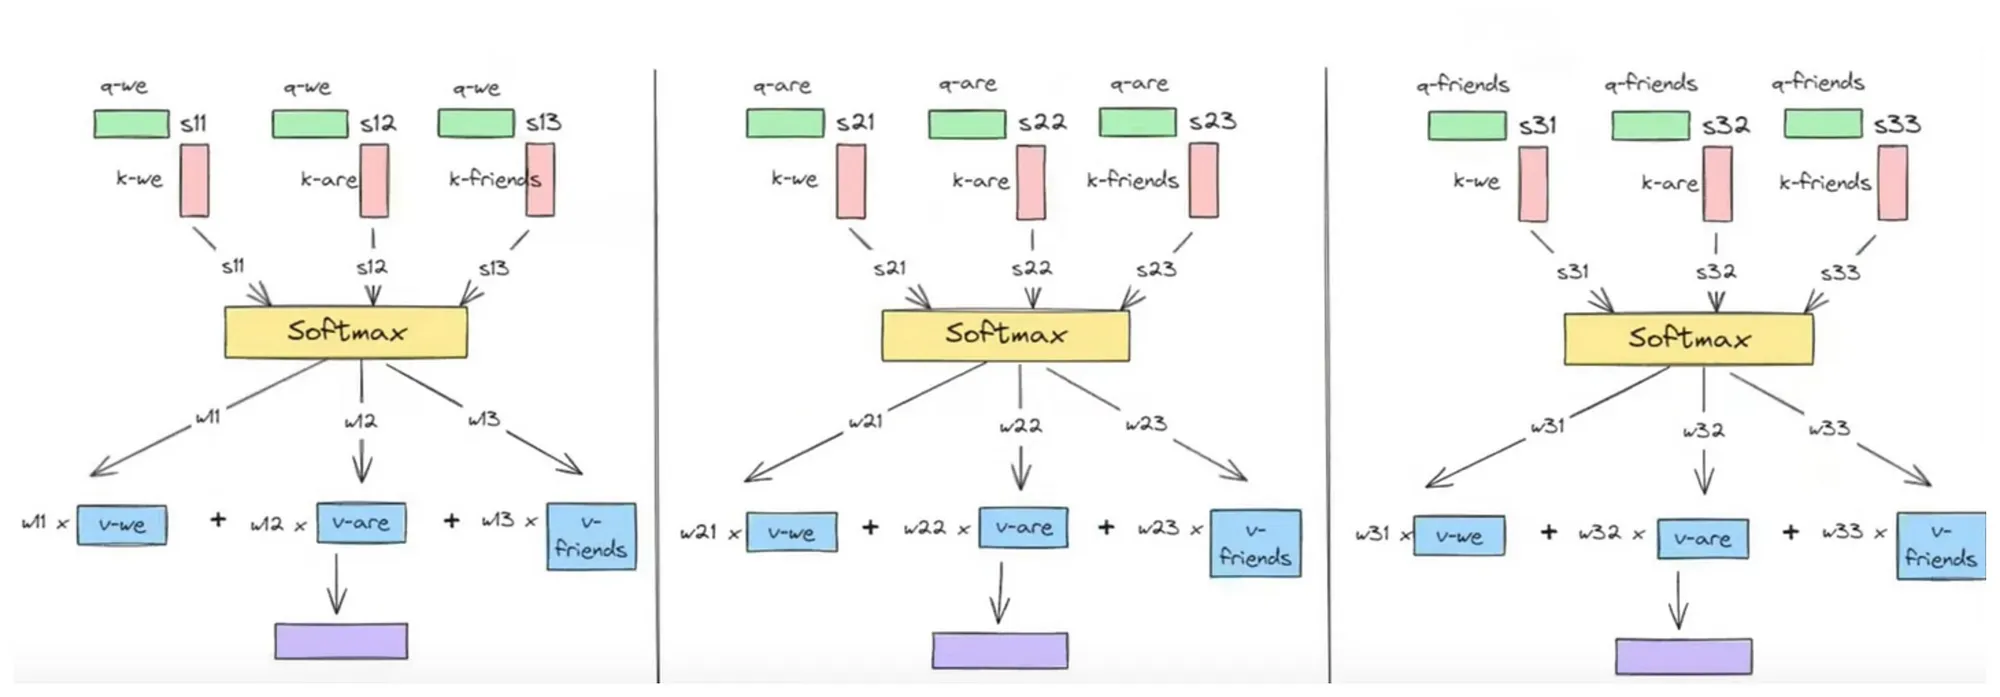

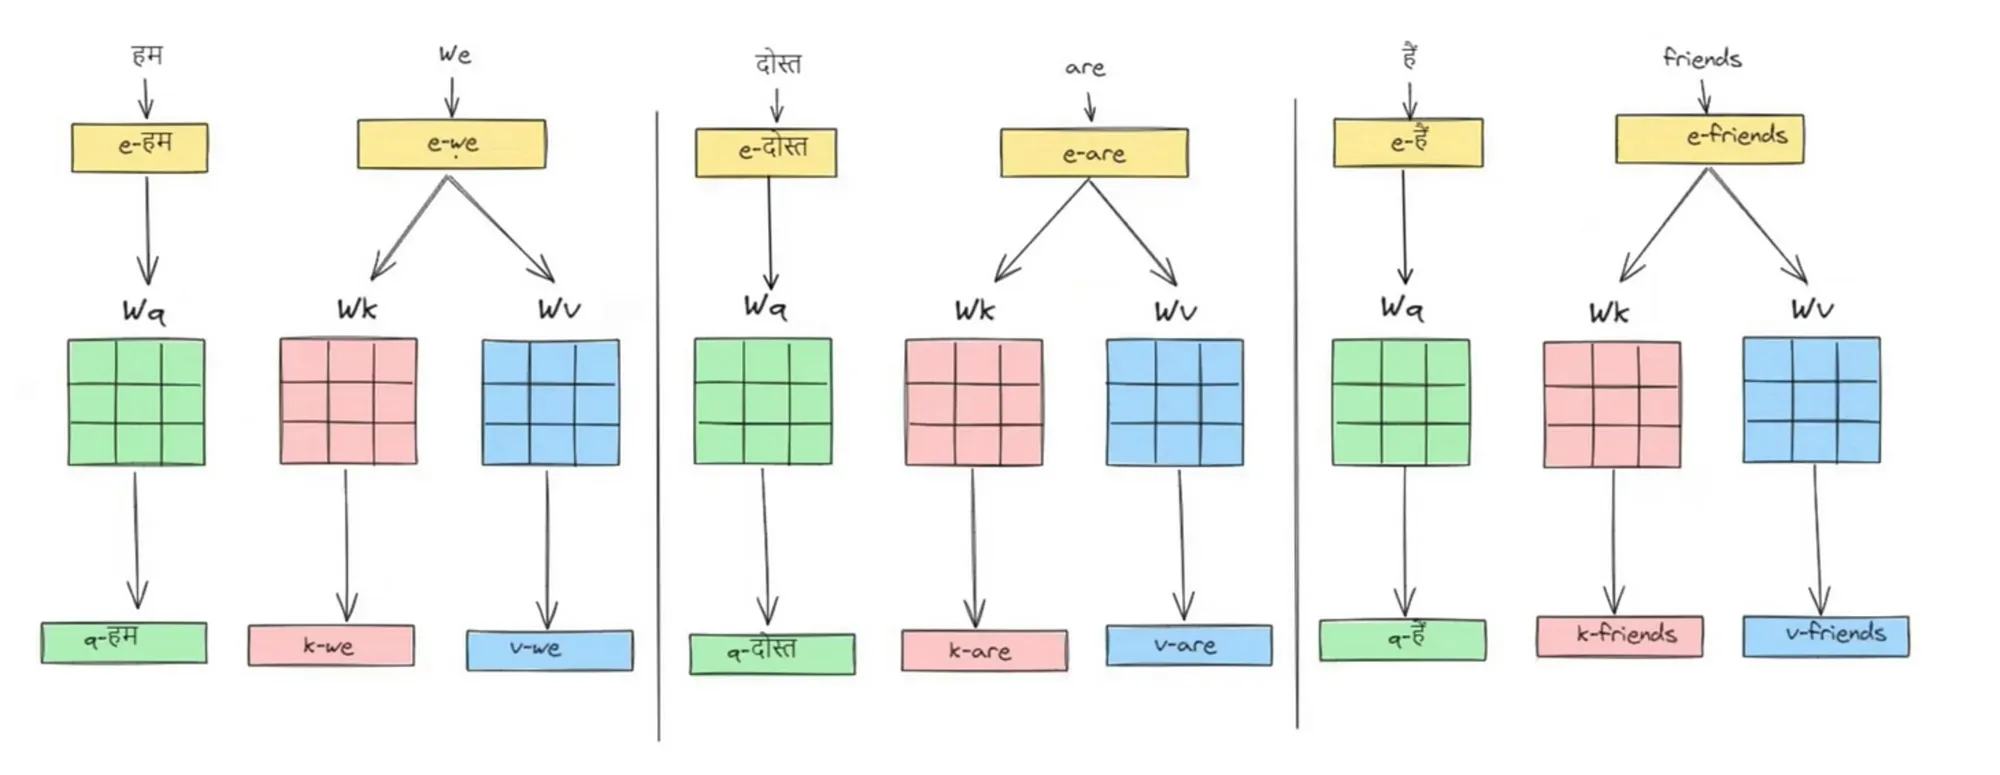

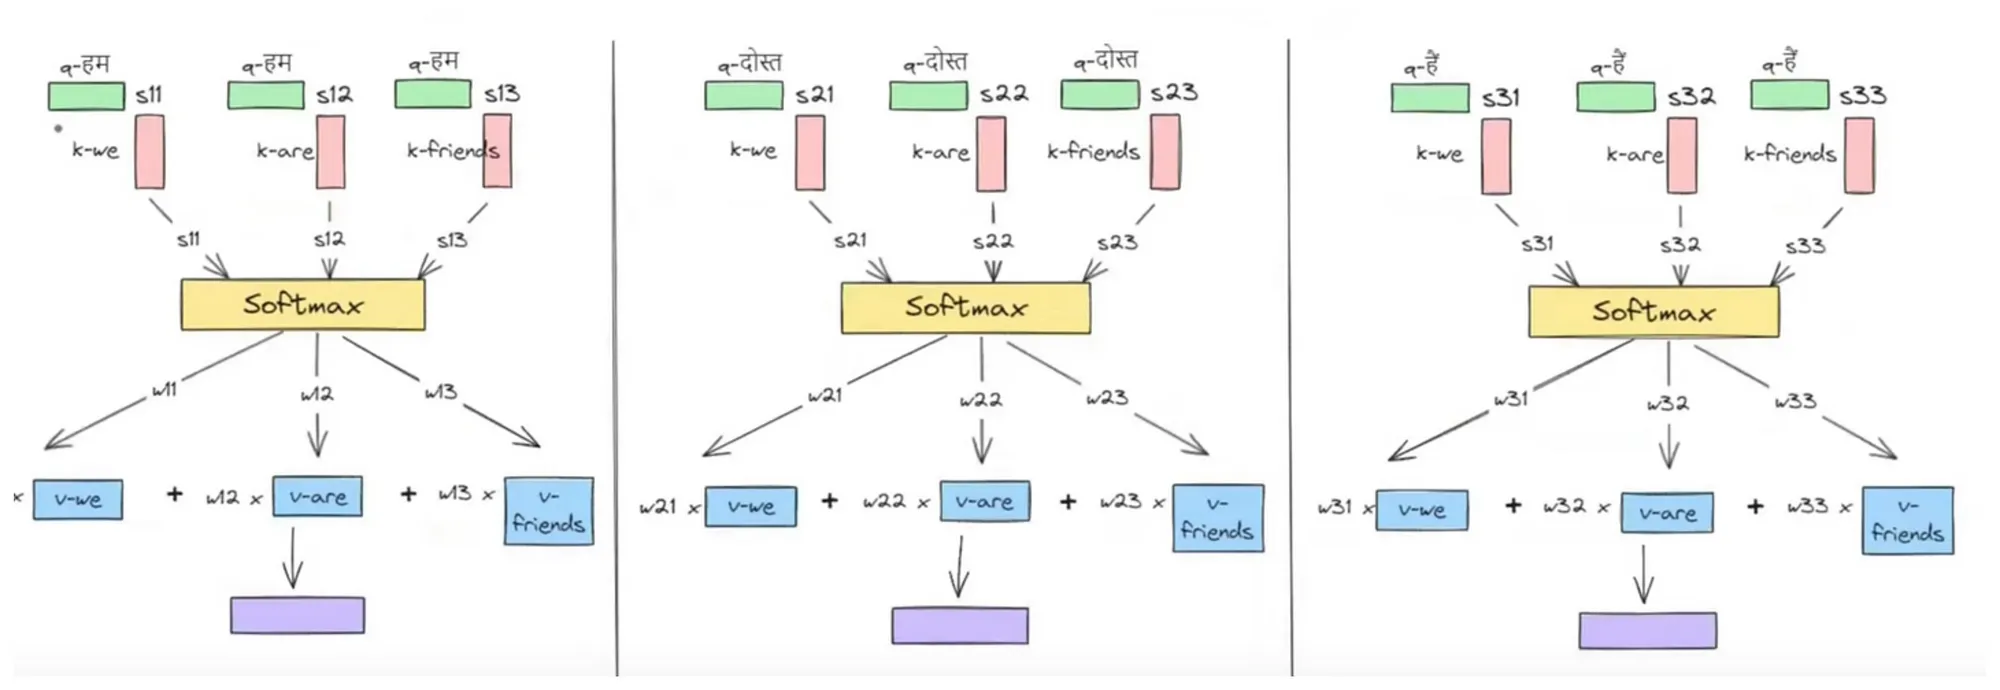

> we can represent the `output of self-attention as a weighted sum of embeddings`. For instance, if we calculate the `contextual embedding` of “We,” it is derived from `the weighted sum of embeddings` of “We,” “are,” and “friends,” where the weights represent the similarity between them. 

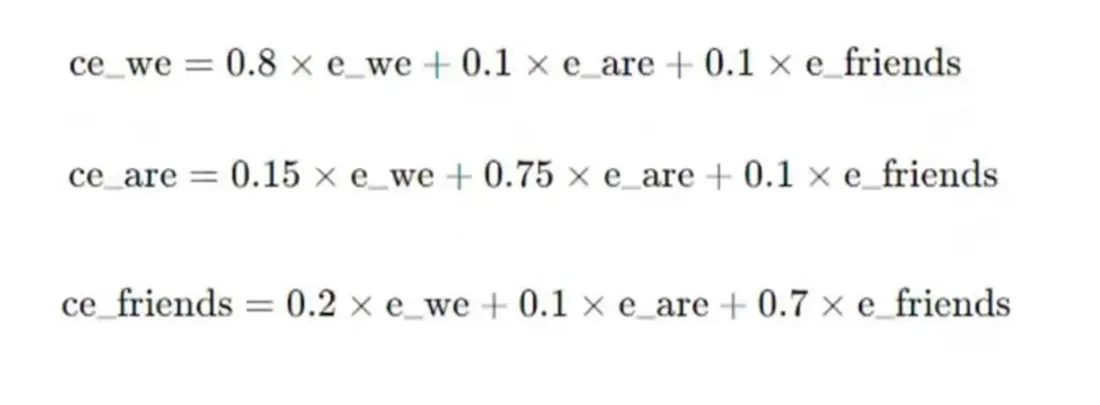

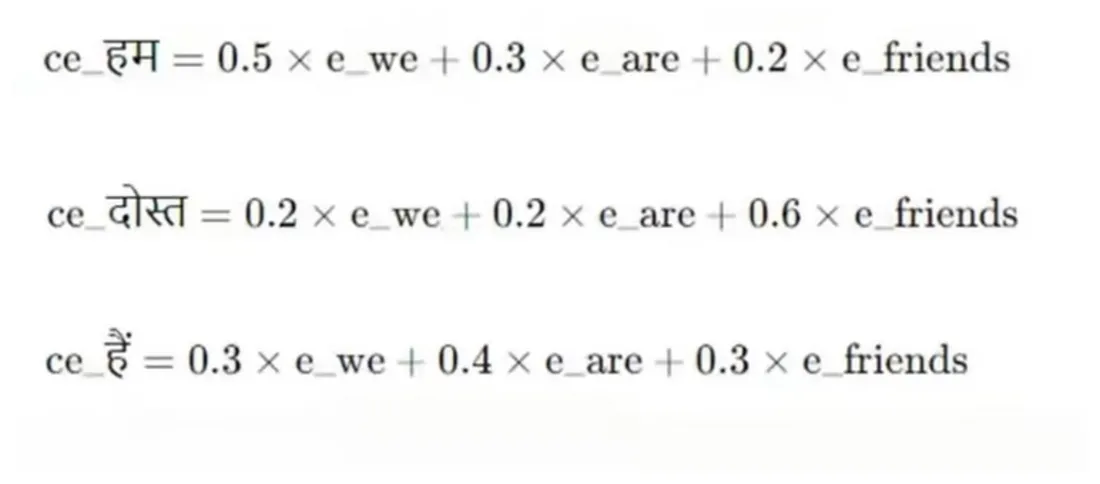


- For example, if the output sequence has three words, like “हम,” “दोस्त,” and “हैं,” 
- you will receive three contextual embeddings: one for each word. These contextual embeddings are also calculated based on the contribution of each input embedding to the output.

> For instance, the contextual embedding for “हम” may consist of contributions from the input embeddings of “We,” “are,” and “friends.”

##### Practical Applications of Cross Attention :

     * Cross-attention is particularly useful in scenarios where there are two distinct sequences involved. Some key applications include:

- Machine Translation: Translating text from one language to another involves comparing and aligning words between the source and target languages.
- Question Answering: Determining which parts of the context are relevant to answer a given question.
- Image Captioning: Generating descriptive text for images, where the image and text are treated as different modalities.
- Text-to-Image Generation: Creating images based on textual descriptions.
- Text-to-Speech: Generating speech from text, where the input is text and the output is speech.

## 🎓 Interview-Ready Summary

> **"Cross-Attention is used inside the Decoder of a Transformer to align and attend to the Encoder’s output. The Decoder uses its own state as a Query and compares it with the Keys from the Encoder to extract relevant context (Values), enabling context-aware output generation."**

---

---

# Bi-Encoder vs Cross-Encoder: Comparison Table

| Feature | Bi-Encoder | Cross-Encoder |
|---|---|---|
| **Input Processing** | Each input encoded **independently** | Both inputs encoded **jointly** (concatenated) |
| **Output** | Two separate embedding vectors | A single relevance/similarity score |
| **Interaction Modeling** | No token-level interaction between inputs; comparison via cosine similarity or dot product | Full token-level cross-attention between both inputs |
| **Speed** | Very fast -- embeddings can be pre-computed and cached | Slow -- must process every pair through the full model |
| **Accuracy** | Good, but misses fine-grained interactions | Superior -- captures nuanced semantic relationships |
| **Scalability** | Excellent -- works with millions/billions of documents via ANN search | Poor -- O(N) forward passes for N candidates |
| **Pre-computation** | Yes -- embeddings stored in vector databases | No -- requires both inputs at inference time |
| **Typical Use** | First-stage retrieval, semantic search, candidate generation | Second-stage re-ranking, NLI, detailed similarity scoring |
| **Training Loss** | Contrastive Loss, Triplet Loss, Multiple Negatives Ranking Loss (MNRL) | Cross-Entropy (classification) or MSE (regression) |
| **Popular Models** | Sentence-BERT (SBERT), E5, GTE, BGE, OpenAI `text-embedding-3-*` | Cross-Encoder models from sentence-transformers, ColBERT (hybrid) |
| **Vector DB Compatible** | Yes | No |
| **Best For** | "Find me the top 100 relevant docs from 10M docs" | "Among these 100 docs, which are truly the best 10?" |

> **Interview Tip:** The most powerful production pattern is a **two-stage pipeline**: Bi-encoder for fast retrieval (recall-focused) followed by Cross-encoder for accurate re-ranking (precision-focused). This combines the speed of Bi-encoders with the accuracy of Cross-encoders.

---

# Retrieval-Augmented Generation (RAG)

---

## What is RAG?

**Retrieval-Augmented Generation (RAG)** is a technique that enhances Large Language Models (LLMs) by grounding their responses in external, up-to-date knowledge retrieved from a document store, rather than relying solely on the model's parametric memory (training data).

> **Core Idea:** Instead of asking the LLM to answer purely from memory, we first **retrieve** relevant documents/passages from an external knowledge base, then **augment** the LLM's prompt with this context, and finally **generate** a grounded answer.

### Why RAG?

| Problem with Vanilla LLMs | How RAG Solves It |
|---|---|
| Knowledge cutoff -- LLM doesn't know recent events | Retrieves from an up-to-date knowledge base |
| Hallucination -- LLM confidently makes up facts | Grounds answers in actual retrieved documents |
| No domain-specific knowledge | Can index proprietary/domain documents |
| Cannot cite sources | Retrieved chunks can be traced back to source documents |
| Expensive to retrain for new knowledge | Just update the document store -- no retraining needed |

## RAG Architecture and Pipeline

### Text-Based RAG Pipeline Diagram

```
================================================================================
                         RAG PIPELINE (End-to-End)
================================================================================

  OFFLINE / INDEXING PHASE                    ONLINE / QUERY PHASE
  ========================                    ======================

  +------------------+                        +------------------+
  | Raw Documents    |                        | User Query       |
  | (PDF, HTML, DB)  |                        | "What is X?"     |
  +--------+---------+                        +--------+---------+
           |                                           |
           v                                           v
  +------------------+                        +------------------+
  | Document Loader  |                        | Query Embedding  |
  | (parse & extract)|                        | (same model as   |
  +--------+---------+                        |  doc embedding)  |
           |                                  +--------+---------+
           v                                           |
  +------------------+                                 v
  | Chunking         |                        +------------------+
  | (split into      |                        | Vector Search    |
  |  passages)       |                        | (ANN: cosine     |
  +--------+---------+                        |  similarity)     |
           |                                  +--------+---------+
           v                                           |
  +------------------+                                 v
  | Embedding Model  |                        +------------------+
  | (Bi-Encoder)     |                        | Top-K Retrieved  |
  | e.g., E5, BGE,   |                        | Chunks           |
  | OpenAI ada-002   |                        +--------+---------+
  +--------+---------+                                 |
           |                                           v  (optional)
           v                                  +------------------+
  +------------------+                        | Re-Ranker        |
  | Vector Database  |                        | (Cross-Encoder)  |
  | (FAISS, Pinecone |<-- similarity search --| Re-score & sort  |
  |  Chroma, Qdrant) |                        +--------+---------+
  +------------------+                                 |
                                                       v
                                              +------------------+
                                              | Prompt Assembly  |
                                              | "Given context:  |
                                              |  {chunks}        |
                                              |  Answer: {query}"|
                                              +--------+---------+
                                                       |
                                                       v
                                              +------------------+
                                              | LLM Generation   |
                                              | (GPT-4, Claude,  |
                                              |  Llama, etc.)    |
                                              +--------+---------+
                                                       |
                                                       v
                                              +------------------+
                                              | Final Answer     |
                                              | (grounded in     |
                                              |  retrieved docs) |
                                              +------------------+
================================================================================
```

### Pipeline Steps Explained

1. **Document Loading:** Ingest raw documents from various sources (PDFs, web pages, databases, APIs).
2. **Chunking:** Split documents into smaller, semantically meaningful passages (see Chunking Strategies below).
3. **Embedding:** Convert each chunk into a dense vector using an embedding model (Bi-encoder).
4. **Indexing:** Store embeddings in a vector database for efficient similarity search.
5. **Query Embedding:** At query time, embed the user's question using the same embedding model.
6. **Retrieval:** Perform approximate nearest neighbor (ANN) search to find the top-K most similar chunks.
7. **Re-Ranking (optional):** Use a Cross-encoder to re-score and re-order the retrieved chunks for better precision.
8. **Prompt Assembly:** Construct a prompt that includes the retrieved context + the user's question.
9. **Generation:** Feed the augmented prompt to an LLM to generate a grounded answer.
10. **Post-processing (optional):** Citation extraction, answer validation, hallucination checks.

## Embedding Models for Retrieval

Embedding models are the backbone of the retrieval stage. They convert text into dense vectors that capture semantic meaning.

### Popular Embedding Models

| Model | Provider | Dimensions | Key Strengths |
|---|---|---|---|
| `text-embedding-3-small/large` | OpenAI | 1536 / 3072 | Strong general-purpose, API-based, dimension reduction support |
| `E5-large-v2` / `E5-mistral-7b` | Microsoft | 1024 / 4096 | Instruction-tuned, excellent on MTEB benchmarks |
| `BGE-large-en-v1.5` | BAAI | 1024 | Open-source, strong on retrieval tasks |
| `GTE-large` | Alibaba | 1024 | Competitive open-source alternative |
| `Cohere Embed v3` | Cohere | 1024 | Supports search_document vs search_query input types |
| `all-MiniLM-L6-v2` | Sentence-Transformers | 384 | Lightweight, fast, good for prototyping |
| `nomic-embed-text` | Nomic AI | 768 | Open-source, long-context (8192 tokens) |
| `Jina Embeddings v2` | Jina AI | 768 | Supports 8192 token context |

### Key Considerations When Choosing an Embedding Model

- **Task alignment:** Was the model trained for retrieval (query-document) or general similarity (sentence-sentence)?
- **Dimension size:** Higher dimensions capture more info but increase storage and compute costs.
- **Context window:** How many tokens can it process? (e.g., 512 vs. 8192)
- **Asymmetric vs. Symmetric:** Some models handle asymmetric search (short query vs. long document) better than symmetric (sentence vs. sentence).
- **Instruction-tuned:** Models like E5 use prefixes like `"query: "` and `"passage: "` to distinguish query and document encodings.
- **Open-source vs. API:** Trade-off between control/cost (open-source) and convenience/performance (API).

> **Interview Tip:** When asked "How would you choose an embedding model?", mention the MTEB leaderboard (Massive Text Embedding Benchmark) as the standard evaluation benchmark for comparing embedding models across tasks like retrieval, classification, clustering, and STS.

## Vector Databases for RAG

Vector databases are specialized storage systems optimized for storing, indexing, and querying high-dimensional vectors using approximate nearest neighbor (ANN) search.

### Comparison of Popular Vector Databases

| Database | Type | Key Features | Best For |
|---|---|---|---|
| **FAISS** | Library (Meta) | Blazing fast, GPU support, multiple index types (IVF, HNSW, PQ), no server needed | Research, prototyping, large-scale in-memory search |
| **Pinecone** | Managed Cloud | Fully managed, auto-scaling, metadata filtering, namespaces | Production SaaS with minimal ops overhead |
| **Chroma** | Open-source | Simple API, embeds in Python, supports metadata, LangChain integration | Prototyping, small-to-medium scale, local development |
| **Weaviate** | Open-source | Hybrid search (vector + keyword), GraphQL API, module ecosystem | Apps needing hybrid search and rich querying |
| **Qdrant** | Open-source | Rust-based (fast), rich filtering, payload storage, gRPC/REST API | High-performance production deployments |
| **Milvus** | Open-source | Distributed, GPU support, multiple index types, high throughput | Enterprise-scale, billion-vector workloads |
| **pgvector** | Postgres Extension | SQL interface, integrates into existing Postgres infra, HNSW index | Teams already using PostgreSQL who want vector search |

### Key ANN Index Types (Frequently Asked)

| Index | How It Works | Trade-off |
|---|---|---|
| **Flat (Brute Force)** | Compares query against every vector | 100% recall, but O(N) -- does not scale |
| **IVF (Inverted File)** | Clusters vectors, only searches relevant clusters | Good speed/recall balance; needs training |
| **HNSW (Hierarchical Navigable Small World)** | Graph-based; navigates through connected nodes | Best recall/speed trade-off; higher memory |
| **PQ (Product Quantization)** | Compresses vectors into smaller codes | Memory efficient; some recall loss |
| **IVF-PQ** | Combines IVF clustering + PQ compression | Handles billion-scale with limited memory |

> **Interview Tip:** When asked "How would you handle RAG at scale with 100M documents?", discuss: (1) IVF-PQ or HNSW indexing, (2) sharding across multiple nodes (Milvus/Qdrant), (3) metadata pre-filtering to reduce search space, and (4) tiered storage (hot/warm).

## Chunking Strategies for RAG

Chunking is one of the most impactful decisions in a RAG pipeline. Poor chunking leads to poor retrieval, which cascades into poor generation.

### Common Chunking Strategies

| Strategy | Description | Pros | Cons |
|---|---|---|---|
| **Fixed-size (token/character)** | Split every N tokens/characters | Simple, predictable chunk sizes | Cuts mid-sentence, breaks semantic units |
| **Fixed-size with overlap** | Fixed-size but with overlapping windows (e.g., 512 tokens, 50 token overlap) | Preserves context at boundaries | Some redundancy in stored chunks |
| **Sentence-based** | Split on sentence boundaries | Preserves complete thoughts | Variable chunk sizes; some sentences too short |
| **Paragraph-based** | Split on paragraph boundaries | Preserves natural document structure | Paragraphs can be very long or very short |
| **Recursive character** | Tries to split on paragraphs, then sentences, then words, then characters | Respects document hierarchy | More complex implementation |
| **Semantic chunking** | Uses embedding similarity to group consecutive sentences into coherent chunks | Best semantic coherence | Slower (requires embedding computation during chunking) |
| **Document-structure-aware** | Uses headings, sections, tables from the document structure | Preserves document logic | Requires parsing document format (HTML, PDF, etc.) |
| **Agentic/Proposition-based** | LLM extracts atomic propositions from text | Each chunk = one fact | Expensive, slower indexing |

### Key Parameters

- **Chunk size:** Typically 256-1024 tokens. Smaller = more precise retrieval but less context; Larger = more context but may include noise.
- **Chunk overlap:** Typically 10-20% of chunk size. Helps preserve context at boundaries.
- **Metadata:** Always attach source document, page number, section heading, etc. to each chunk.

### Interview-Ready Guidelines

1. Start with **recursive character splitting** (LangChain default) as a baseline.
2. Use **chunk sizes around 512 tokens** with **50-100 token overlap** as a starting point.
3. For structured documents (code, legal, medical), use **document-structure-aware** chunking.
4. For maximum quality, try **semantic chunking** (e.g., using LlamaIndex's `SemanticSplitterNodeParser`).
5. Always **evaluate** different strategies using retrieval metrics (Recall@K, MRR) on your specific data.

> **Interview Tip:** If asked "Your RAG system returns irrelevant results -- how do you debug?", chunking is one of the first things to investigate. Bad chunk boundaries are a leading cause of retrieval failures.

## RAG Evaluation Metrics

Evaluating RAG systems is challenging because you need to assess both the **retrieval** quality and the **generation** quality. The RAGAS framework provides a standard set of metrics.

### Retrieval Metrics

| Metric | What It Measures | Formula / Intuition |
|---|---|---|
| **Context Precision** | Are the retrieved chunks relevant to the question? | Fraction of retrieved chunks that are actually relevant |
| **Context Recall** | Did we retrieve all the relevant information? | Fraction of ground-truth relevant information that was retrieved |
| **Hit Rate / Recall@K** | Is at least one relevant document in the top-K? | 1 if any relevant doc is in top-K, 0 otherwise |
| **MRR (Mean Reciprocal Rank)** | How high is the first relevant document ranked? | 1/rank of first relevant document, averaged across queries |
| **NDCG (Normalized Discounted Cumulative Gain)** | Quality of the full ranking | Rewards relevant docs ranked higher; penalizes relevant docs ranked lower |

### Generation Metrics

| Metric | What It Measures | How It Works |
|---|---|---|
| **Answer Faithfulness** | Is the answer grounded in the retrieved context? (No hallucination) | LLM-as-judge checks if each claim in the answer is supported by the context |
| **Answer Relevance** | Does the answer actually address the question? | LLM generates questions from the answer; checks similarity to original question |
| **Answer Correctness** | Is the answer factually correct? | Compared against a ground-truth answer (if available) |

### End-to-End Metrics

| Metric | What It Measures |
|---|---|
| **Context Relevance** | Overall: Is the retrieved context relevant and sufficient for answering the question? |
| **Answer Similarity** | Semantic similarity between generated answer and ground-truth answer |
| **Latency** | End-to-end response time (retrieval + generation) |
| **Cost** | Token usage and API costs per query |

### Evaluation Frameworks

- **RAGAS** -- Most popular RAG evaluation framework; computes faithfulness, relevance, context precision/recall
- **DeepEval** -- Comprehensive evaluation with hallucination detection
- **LangSmith** -- LangChain's tracing and evaluation platform
- **TruLens** -- Feedback functions for RAG evaluation
- **Custom LLM-as-Judge** -- Use a strong LLM (e.g., GPT-4) to score outputs on custom rubrics

> **Interview Tip:** When asked "How would you evaluate your RAG system?", structure your answer around the three pillars: (1) Retrieval quality (precision, recall, MRR), (2) Generation quality (faithfulness, relevance), and (3) End-to-end metrics (latency, cost, user satisfaction).

## RAG vs Fine-Tuning: When to Use Which

This is one of the most frequently asked interview questions in the LLM/GenAI space.

| Dimension | RAG | Fine-Tuning |
|---|---|---|
| **Knowledge source** | External documents (retrieved at query time) | Baked into model weights during training |
| **Knowledge freshness** | Always up-to-date (just update the doc store) | Stale after training; requires retraining for updates |
| **Hallucination control** | Better -- answers grounded in retrieved docs | Harder to control; model may still hallucinate |
| **Cost** | Lower upfront; higher per-query (retrieval + LLM) | Higher upfront (GPU training); lower per-query |
| **Latency** | Higher (retrieval adds latency) | Lower (single forward pass) |
| **Domain adaptation** | Good for factual Q&A over specific documents | Better for style, tone, format, and task adaptation |
| **Data privacy** | Documents stay in your infra; not sent to training | Training data may leak into model weights |
| **Transparency** | Can cite sources and show retrieved chunks | Black box -- hard to trace where knowledge comes from |
| **Setup complexity** | Moderate (embedding, vector DB, retrieval pipeline) | High (data prep, training infra, evaluation, deployment) |
| **Best for** | Factual Q&A, customer support, documentation search, knowledge bases | Code generation, specific writing style, domain-specific reasoning, classification |

### Decision Framework

```
START
  |
  +-- Does the model need to know specific, frequently updated facts?
  |     YES --> RAG
  |     NO  --+
  |           |
  +-- Do you need the model to behave differently (style, format, tone)?
  |     YES --> Fine-Tuning
  |     NO  --+
  |           |
  +-- Do you need both updated facts AND specialized behavior?
  |     YES --> RAG + Fine-Tuning (combined approach)
  |     NO  --+
  |           |
  +-- Is the base model already good enough with prompt engineering?
        YES --> Neither (just use good prompts)
        NO  --> Evaluate case-by-case
```

### Combined Approach: RAG + Fine-Tuning

In production, many systems combine both:
- **Fine-tune** the LLM to better follow instructions, produce structured output, or reason in a domain-specific way.
- **Use RAG** to inject up-to-date factual knowledge at query time.
- **Fine-tune the embedding model** on domain-specific data for better retrieval.

> **Interview Tip:** Never present RAG and fine-tuning as mutually exclusive. The strongest answer shows you understand they are complementary and can be combined.

## Advanced RAG Techniques

Naive RAG (embed-retrieve-generate) has known limitations. Advanced RAG techniques address specific failure modes.

### 1. HyDE (Hypothetical Document Embeddings)

**Problem:** User queries are often short and lack context, making them poor candidates for semantic similarity matching against long document chunks.

**Solution:** Use the LLM to generate a **hypothetical answer** to the query, then embed that hypothetical answer (instead of the raw query) for retrieval.

```
User Query: "What causes aurora borealis?"
     |
     v
LLM generates hypothetical answer:
  "Aurora borealis is caused by charged particles from the sun
   interacting with Earth's magnetic field and atmosphere..."
     |
     v
Embed this hypothetical answer --> search vector DB
     |
     v
Retrieved chunks are more aligned with the answer style
```

**Why it works:** The hypothetical answer is closer in embedding space to the actual document chunks than the short query would be.

---

### 2. Query Decomposition / Multi-step Retrieval

**Problem:** Complex questions require information from multiple sources or multiple reasoning steps.

**Solution:** Break the original query into sub-queries, retrieve for each, then synthesize.

**Variants:**
- **Step-back prompting:** Ask a more general question first, retrieve broader context, then answer the specific question.
- **Sub-question decomposition:** Split "Compare X and Y" into "What is X?" and "What is Y?" -- retrieve separately, then combine.
- **Iterative retrieval:** Use the answer from one retrieval step to formulate the next query.

---

### 3. Re-Ranking

**Problem:** Bi-encoder retrieval optimizes for recall but may rank less relevant results higher.

**Solution:** Use a **Cross-encoder** re-ranker to re-score and re-order the top-K retrieved chunks.

**Popular re-rankers:**
- `cross-encoder/ms-marco-MiniLM-L-6-v2` (sentence-transformers)
- Cohere Rerank API
- `bge-reranker-large` (BAAI)
- ColBERT (late-interaction model -- a middle ground between Bi-encoder and Cross-encoder)

---

### 4. Hybrid Search (Sparse + Dense)

**Problem:** Dense (semantic) retrieval can miss exact keyword matches; sparse (BM25) retrieval misses semantic similarity.

**Solution:** Combine both and fuse results.

```
Query --> BM25 (keyword search)   --> Results A
Query --> Dense retrieval (vector) --> Results B
                                        |
                                        v
                              Reciprocal Rank Fusion (RRF)
                                        |
                                        v
                                 Merged top-K results
```

---

### 5. Parent Document Retrieval / Small-to-Big

**Problem:** Small chunks give precise retrieval but lack surrounding context for the LLM.

**Solution:** Retrieve small chunks for precision, but pass the **parent (larger) chunk or full document** to the LLM for generation.

---

### 6. Contextual Compression

**Problem:** Retrieved chunks may contain a lot of irrelevant information mixed with the relevant parts.

**Solution:** Use an LLM or smaller model to **extract or compress** only the relevant portions from each retrieved chunk before passing to the generator.

---

### 7. Self-RAG (Self-Reflective RAG)

**Problem:** The model does not know when to retrieve and when its own knowledge is sufficient.

**Solution:** Train the model to emit special tokens that decide: (1) whether to retrieve, (2) whether retrieved docs are relevant, and (3) whether the generated answer is supported by the docs.

---

### 8. RAPTOR (Recursive Abstractive Processing for Tree-Organized Retrieval)

**Problem:** Standard RAG retrieves individual chunks and misses high-level themes and summaries.

**Solution:** Build a **tree of summaries** -- cluster chunks, summarize clusters, cluster summaries, and so on. At query time, retrieve from multiple levels of the tree.

---

### Summary Table of Advanced Techniques

| Technique | Addresses | Complexity |
|---|---|---|
| HyDE | Poor query-document alignment | Low |
| Query Decomposition | Complex multi-part questions | Medium |
| Re-Ranking (Cross-Encoder) | Imprecise ranking from Bi-encoder | Low |
| Hybrid Search (BM25 + Dense) | Missed keyword matches | Medium |
| Parent Document Retrieval | Insufficient context in small chunks | Low |
| Contextual Compression | Noisy/irrelevant content in chunks | Medium |
| Self-RAG | Unnecessary/harmful retrieval | High |
| RAPTOR | Missing high-level understanding | High |

---

# Top 12 RAG & Retrieval Interview Questions with Answers

---

### Q1: What is the difference between a Bi-encoder and a Cross-encoder?

**Answer:** A Bi-encoder encodes each input independently into a fixed-size vector, then compares them using a similarity metric like cosine similarity. A Cross-encoder concatenates both inputs and processes them jointly through a single transformer, producing a relevance score directly. Bi-encoders are fast and scalable (embeddings can be pre-computed), while Cross-encoders are more accurate but require a forward pass for every pair, making them unsuitable for large-scale retrieval. In practice, they are used together: Bi-encoder for fast candidate retrieval, Cross-encoder for re-ranking the top-K results.

---

### Q2: Explain the RAG architecture. What are the key components?

**Answer:** RAG has two phases:
- **Offline/Indexing:** Documents are loaded, chunked into passages, embedded using a Bi-encoder, and stored in a vector database.
- **Online/Query:** The user's query is embedded, similar chunks are retrieved via ANN search, optionally re-ranked, and then the retrieved context + query are passed to an LLM for answer generation.

Key components: Document loader, chunking module, embedding model, vector database, retriever, (optional) re-ranker, prompt template, and the LLM generator.

---

### Q3: How do you handle the trade-off between chunk size and retrieval quality?

**Answer:** Smaller chunks (e.g., 256 tokens) give more precise retrieval -- the retrieved text closely matches the query. However, they provide less context for the LLM. Larger chunks (e.g., 1024 tokens) give more context but may include irrelevant content, diluting relevance. The solution is:
1. Start with 512 tokens and 50-100 token overlap as a baseline.
2. Use the "small-to-big" pattern: retrieve small chunks but pass parent (larger) chunks to the LLM.
3. Evaluate using retrieval metrics (Recall@K, MRR) on a dev set to tune the optimal size for your data.

---

### Q4: What is HyDE and when would you use it?

**Answer:** HyDE (Hypothetical Document Embeddings) addresses the query-document mismatch problem. Short user queries often have poor semantic overlap with long document passages. HyDE uses the LLM to generate a hypothetical answer, then embeds that answer for retrieval. The hypothetical answer is stylistically and semantically closer to actual document passages, improving retrieval quality. Use HyDE when: (1) queries are short or ambiguous, (2) there is a significant asymmetry between query and document length/style, and (3) you can tolerate the added latency of an extra LLM call.

---

### Q5: How would you evaluate a RAG system?

**Answer:** Evaluate at three levels:
- **Retrieval:** Context Precision (are retrieved chunks relevant?), Context Recall (did we retrieve all relevant info?), MRR, NDCG.
- **Generation:** Faithfulness (is the answer grounded in the context -- no hallucination?), Answer Relevance (does it address the question?).
- **End-to-end:** Answer Correctness (against ground truth), Latency, Cost.

Use frameworks like RAGAS or DeepEval. For production, also track user feedback (thumbs up/down) and conduct periodic human evaluation.

---

### Q6: When would you use RAG vs Fine-tuning?

**Answer:**
- **RAG** when: you need up-to-date factual knowledge, citation/source tracing, domain-specific Q&A over documents, and want to avoid retraining.
- **Fine-tuning** when: you need to change the model's behavior, style, or reasoning patterns, or when the task requires specialized output format.
- **Both** when: you need domain-adapted behavior AND up-to-date knowledge (e.g., fine-tune for medical reasoning + RAG for latest research papers).

The key insight is that RAG adds **knowledge** while fine-tuning changes **behavior**. They are complementary, not alternatives.

---

### Q7: Your RAG system is hallucinating. How do you debug and fix it?

**Answer:** Diagnose step by step:
1. **Check retrieval:** Are the retrieved chunks actually relevant? If not, the problem is retrieval (fix chunking, embedding model, or add re-ranking).
2. **Check context sufficiency:** Even if chunks are relevant, do they contain enough information to answer the question? If not, increase chunk size or retrieve more chunks.
3. **Check the prompt:** Does the system prompt clearly instruct the LLM to only use the provided context? Add instructions like "If the answer is not in the context, say 'I don't know'."
4. **Check the LLM:** Some models hallucinate more than others. Try a more capable model or lower the temperature.
5. **Add guardrails:** Implement faithfulness checking (e.g., NLI-based) on the output before returning to the user.

---

### Q8: What are the key differences between FAISS, Pinecone, and Chroma?

**Answer:**
- **FAISS** (Meta): A library, not a database. Runs in-memory, blazing fast, supports GPU. Best for research and scenarios where you manage your own infrastructure. No built-in persistence or filtering.
- **Pinecone**: Fully managed cloud service. Easy to set up, auto-scales, supports metadata filtering and namespaces. Best for production with minimal DevOps.
- **Chroma**: Open-source, embeddable in Python. Simple API, great LangChain integration. Best for prototyping and small-to-medium workloads.

Choice depends on: scale (FAISS/Pinecone for billions, Chroma for smaller), operational burden (Pinecone = zero ops), and budget (FAISS/Chroma = free, Pinecone = paid).

---

### Q9: Explain the two-stage retrieval pipeline (retrieve + re-rank).

**Answer:** Stage 1 uses a Bi-encoder to quickly retrieve the top-K (e.g., K=100) candidates from a large corpus using ANN search. This is optimized for **recall** -- cast a wide net. Stage 2 uses a Cross-encoder to re-score each of the K candidates by processing the (query, document) pair jointly. This is optimized for **precision** -- accurately identify the best results. The re-ranked top-N (e.g., N=5) are passed to the LLM. This combines the Bi-encoder's scalability with the Cross-encoder's accuracy.

---

### Q10: What is hybrid search and why is it useful?

**Answer:** Hybrid search combines dense retrieval (vector/semantic similarity) with sparse retrieval (keyword-based, like BM25). Dense retrieval excels at semantic understanding ("car" matches "automobile") but can miss exact keyword matches. BM25 excels at exact matches and rare terms but misses semantic relationships. Combining them using Reciprocal Rank Fusion (RRF) or weighted scoring gives the best of both worlds. Most production RAG systems use hybrid search.

---

### Q11: How do you handle multi-hop or complex questions in RAG?

**Answer:** Standard RAG retrieves once and generates, which fails for questions requiring multiple reasoning steps. Solutions:
- **Query decomposition:** Break the complex question into sub-questions, retrieve for each, and synthesize.
- **Iterative retrieval:** Retrieve, generate a partial answer, use it to formulate the next query, retrieve again.
- **Graph-based RAG:** Use knowledge graphs to traverse relationships between entities.
- **Agentic RAG:** Use an LLM agent that can decide when to retrieve, what to retrieve, and when it has enough information to answer. Frameworks like LangGraph support this.

---

### Q12: How would you build a RAG system for a company with 10 million internal documents?

**Answer:** Key design decisions:
1. **Chunking:** Use recursive or structure-aware chunking with metadata (department, date, author, doc type).
2. **Embedding:** Use a strong model like E5 or BGE; consider fine-tuning on domain data if needed.
3. **Vector DB:** Use a scalable solution like Milvus, Qdrant, or Pinecone. Use IVF-PQ or HNSW indexing for the 10M scale.
4. **Hybrid search:** Combine BM25 + dense retrieval for robustness.
5. **Re-ranking:** Add a Cross-encoder re-ranker for the top-50 results.
6. **Access control:** Implement document-level permissions so users only retrieve documents they have access to (metadata filtering).
7. **Incremental indexing:** Set up a pipeline to embed and index new documents as they are created/updated.
8. **Caching:** Cache frequent query embeddings and results.
9. **Evaluation:** Build a test set of common queries with ground-truth answers; monitor retrieval and generation metrics continuously.
10. **Monitoring:** Track latency, cost, user satisfaction, and hallucination rates in production.

---

# "Explain RAG to a Non-Technical Person"

> **Interview Tip:** Many interviews (especially for senior roles) test your ability to explain complex concepts simply. Here is a ready-made analogy:

**The Library Analogy:**

> Imagine you have a really smart friend who has read thousands of books but their memory is not perfect -- sometimes they mix things up or forget details. That is like an AI language model.
>
> Now imagine you give your friend a specific question. Instead of asking them to answer from memory alone, you first go to a library, find the 3-5 most relevant pages, hand those pages to your friend, and say: "Read these pages and then answer my question based on what you just read."
>
> That is RAG: **Retrieval-Augmented Generation**.
>
> - The **library** is your document database.
> - The **librarian who finds the right pages** is the retrieval system (embedding model + vector database).
> - Your **smart friend reading the pages and answering** is the language model.
>
> The result? Your friend gives more accurate, up-to-date answers because they are looking at the actual source material, not just relying on their (sometimes faulty) memory.

**Key phrases for non-technical stakeholders:**
- "It grounds AI answers in your actual company documents."
- "It reduces AI hallucination by giving the model reference material."
- "Think of it as giving the AI an open-book exam instead of a closed-book exam."
- "Your data stays in your control -- it is retrieved at query time, not memorized by the AI."

---

*End of notebook. Good luck with your interview!*

---
---

# PART 2: Advanced RAG Techniques, Agentic Systems & Production Deployment (2024-2026)

> **Scope:** This section covers the latest advances in RAG beyond the basics -- GraphRAG, Corrective RAG, Self-RAG, Adaptive RAG, Modular RAG, Agentic RAG, Multi-modal RAG, Long-context RAG, multi-agent system design, production deployment strategies, and real-world case studies. Optimized for senior ML/AI interview preparation.

> **Key References:**
> - Microsoft GraphRAG (2024) -- https://microsoft.github.io/graphrag/
> - Self-RAG: Asai et al. (2023) -- arXiv:2310.11511
> - Corrective RAG: Yan et al. (2024) -- arXiv:2401.15884
> - Adaptive-RAG: Jeong et al. (2024, NAACL) -- arXiv:2403.14403
> - Modular RAG: arXiv:2407.21059
> - Agentic RAG Survey: Singh et al. (2025) -- arXiv:2501.09136
> - VisRAG: Yu et al. (2024) -- arXiv:2410.10594
> - Anthropic "Building Effective Agents" (2024) -- https://www.anthropic.com/engineering/building-effective-agents
> - Andrew Ng's Agentic Design Patterns -- https://www.deeplearning.ai/the-batch/how-agents-can-improve-llm-performance/
> - Azure AI Search Hybrid Retrieval -- Microsoft Tech Community Blog (2023)
> - Galileo Enterprise RAG Guide -- https://www.galileo.ai/blog/mastering-rag-how-to-architect-an-enterprise-rag-system
> - Anyscale Production RAG Guide -- https://www.anyscale.com/blog/a-comprehensive-guide-for-building-rag-based-llm-applications-part-1

---

# Section 1: Latest RAG Techniques (2024-2026)

The RAG landscape has evolved dramatically beyond naive "retrieve-and-generate." This section covers eight advanced RAG paradigms that represent the state of the art.

## Evolution of RAG Paradigms

```
===================================================================================
                        EVOLUTION OF RAG (2020-2026)
===================================================================================

  Naive RAG (2020-2022)          Advanced RAG (2023-2024)         Modular/Agentic RAG (2024-2026)
  ====================           =======================          ==============================
                                                                  
  Query --> Retrieve -->         Query Transform -->              Agent decides:
  Generate                       Hybrid Search -->                 - WHETHER to retrieve
                                 Re-rank -->                       - WHAT to retrieve
  Problems:                      Compress -->                      - HOW to validate
  - Poor retrieval               Generate                          - WHEN to stop
  - No validation                                                  - WHICH tools to use
  - Hallucinations               Improvements:                    
  - No iteration                 - Better retrieval               Capabilities:
                                 - Re-ranking                     - Multi-step reasoning
                                 - Query rewriting                - Self-reflection
                                 - Hybrid search                  - Graph traversal
                                                                  - Multi-modal retrieval
                                                                  - Autonomous decision-making
===================================================================================
```

---

## 1.1 GraphRAG (Microsoft, 2024)

**Paper/Project:** "GraphRAG: Unlocking LLM Discovery on Narrative Private Data" -- Microsoft Research (2024)
**Link:** https://microsoft.github.io/graphrag/

### What is GraphRAG?

GraphRAG is a **structured, hierarchical approach to RAG** that constructs a knowledge graph from source documents, then uses graph-based community detection and summarization to answer both **local** (entity-specific) and **global** (corpus-level) questions. It dramatically outperforms naive vector-search RAG on questions requiring synthesis across multiple documents.

### Why GraphRAG? (Limitations of Naive RAG it solves)

| Problem with Naive RAG | How GraphRAG Solves It |
|---|---|
| Cannot "connect the dots" across documents | Knowledge graph captures cross-document entity relationships |
| Fails at global/thematic questions ("What are the top themes?") | Community summaries provide corpus-level understanding |
| No holistic understanding of the dataset | Hierarchical clustering creates multi-level abstractions |
| Retrieval limited to local similarity | Graph traversal enables multi-hop reasoning |

### Architecture & Indexing Pipeline

```
===================================================================================
                        GraphRAG INDEXING PIPELINE
===================================================================================

  +--------------------+
  | Raw Documents      |     Step 1: Text Segmentation
  | (corpus of text)   | --> Split into TextUnits (analyzable chunks)
  +--------------------+
           |
           v
  +--------------------+
  | LLM Entity &       |     Step 2: Entity/Relationship Extraction
  | Relationship        | --> LLM identifies entities (people, places, orgs)
  | Extraction          |     and relationships between them
  +--------------------+
           |
           v
  +--------------------+
  | Knowledge Graph     |     Step 3: Graph Construction
  | Construction        | --> Entities = Nodes, Relationships = Edges
  +--------------------+
           |
           v
  +--------------------+
  | Leiden Community    |     Step 4: Hierarchical Community Detection
  | Detection           | --> Cluster related entities into communities
  +--------------------+         at multiple hierarchy levels
           |
           v
  +--------------------+
  | Community           |     Step 5: Bottom-Up Summarization
  | Summarization       | --> LLM generates summaries for each community
  +--------------------+         at each level of the hierarchy

===================================================================================
```

### Query Modes

| Mode | How It Works | Best For |
|---|---|---|
| **Global Search** | Uses community summaries across the entire graph to answer | Corpus-level questions: "What are the main themes?" |
| **Local Search** | Starts from specific entities, expands to neighbors | Entity-specific questions: "What has X done?" |
| **DRIFT Search** | Like local search but enriched with community context | Nuanced entity questions needing broader context |

### Key Results (Microsoft)

- GraphRAG **consistently outperforms** baseline RAG on comprehensiveness, contextual grounding, and viewpoint diversity
- On the question "What are the top 5 themes in this dataset?", baseline RAG completely failed (vector similarity had no guidance), while GraphRAG succeeded by leveraging community structure
- Factual faithfulness remained comparable to baseline (verified via SelfCheckGPT)

### Interview-Ready Summary

> **"GraphRAG constructs a knowledge graph from documents using LLM-based entity/relationship extraction, then applies hierarchical community detection (Leiden algorithm) and summarization. It supports local search (entity-focused, expanding through graph neighbors) and global search (using community summaries for corpus-level questions). It excels where naive RAG fails: multi-hop reasoning, cross-document synthesis, and thematic/global questions."**

---

## 1.2 Corrective RAG (CRAG) -- Yan et al., 2024

**Paper:** "Corrective Retrieval Augmented Generation" -- arXiv:2401.15884
**Authors:** Shi-Qi Yan, Jia-Chen Gu, Yun Zhu, Zhen-Hua Ling

### What is CRAG?

CRAG addresses the **critical vulnerability** of standard RAG: what happens when retrieval fails or returns low-quality documents? Instead of blindly passing bad context to the LLM (causing hallucination), CRAG adds a **lightweight retrieval evaluator** that assesses document quality and triggers corrective actions.

### Architecture

```
===================================================================================
                        CORRECTIVE RAG (CRAG) PIPELINE
===================================================================================

  User Query
       |
       v
  +-----------+         +-------------------+
  | Retriever | ------> | Retrieval         |
  +-----------+         | Evaluator         |
                        | (Confidence Score)|
                        +--------+----------+
                                 |
                    +------------+------------+
                    |            |            |
                    v            v            v
              [CORRECT]    [AMBIGUOUS]   [INCORRECT]
                    |            |            |
                    v            v            v
              Use retrieved  Combine       Trigger web
              docs as-is    retrieved +   search for
                            web results   supplementary
                                          documents
                    |            |            |
                    +------------+------------+
                                 |
                                 v
                    +------------------------+
                    | Knowledge Refinement   |
                    | (Decompose-Recompose)  |
                    | Extract key info,      |
                    | filter irrelevant      |
                    +------------------------+
                                 |
                                 v
                    +------------------------+
                    | LLM Generation         |
                    | (with refined context) |
                    +------------------------+

===================================================================================
```

### Key Innovation: Three-Way Confidence Routing

| Confidence Level | Action | Rationale |
|---|---|---|
| **Correct** (high confidence) | Use retrieved documents directly | Documents are relevant; proceed normally |
| **Ambiguous** (medium confidence) | Combine retrieved docs + web search results | Hedge bets by supplementing with external sources |
| **Incorrect** (low confidence) | Discard retrieved docs; use web search instead | Retrieved docs would cause hallucination; start fresh |

### Knowledge Refinement: Decompose-Then-Recompose

After retrieval correction, CRAG applies a refinement step:
1. **Decompose** each retrieved document into fine-grained knowledge strips
2. **Filter** irrelevant strips using the evaluator
3. **Recompose** only the relevant strips into a clean context for the LLM

### Key Results
- Significant improvements across four datasets (both short-form and long-form generation)
- **Plug-and-play**: works with any existing RAG pipeline without architectural changes
- Robust against retrieval failures that would cause standard RAG to hallucinate

### Interview-Ready Summary

> **"CRAG adds a lightweight retrieval evaluator that scores document relevance as correct/ambiguous/incorrect. High-confidence results proceed normally. Low-confidence results trigger web search as a fallback. A decompose-then-recompose algorithm further refines retrieved content by extracting only relevant knowledge strips. It is plug-and-play -- can be added to any existing RAG system."**

---

## 1.3 Self-RAG -- Asai et al., 2023

**Paper:** "Self-RAG: Learning to Retrieve, Generate, and Critique through Self-Reflection" -- arXiv:2310.11511
**Authors:** Akari Asai, Zeqiu Wu, Yizhong Wang, Avirup Sil, Hannaneh Hajishirzi

### What is Self-RAG?

Self-RAG trains the LLM itself to decide **when to retrieve**, **evaluate retrieved documents**, and **critique its own generation** using special **reflection tokens**. Unlike standard RAG (which always retrieves) or CRAG (which uses an external evaluator), Self-RAG makes the model intrinsically self-aware about retrieval needs.

### Architecture with Reflection Tokens

```
===================================================================================
                        SELF-RAG PIPELINE
===================================================================================

  User Query
       |
       v
  +-------------------+
  | LLM decides:      |     Reflection Token: [Retrieve]
  | Do I need to      |     YES --> trigger retrieval
  | retrieve?         |     NO  --> generate from parametric memory
  +--------+----------+
           |
           v (if YES)
  +-------------------+
  | Retrieve top-K    |
  | passages          |
  +--------+----------+
           |
           v
  +-------------------+
  | LLM evaluates     |     Reflection Token: [IsRelevant]
  | each passage:     |     Relevant / Irrelevant
  | Is this relevant? |
  +--------+----------+
           |
           v
  +-------------------+
  | LLM generates     |
  | answer segment    |
  | using relevant    |
  | passages          |
  +--------+----------+
           |
           v
  +-------------------+
  | LLM critiques     |     Reflection Token: [IsSupported]
  | its own output:   |     Fully Supported / Partially / No Support
  | Is this grounded  |
  | in the evidence?  |
  +--------+----------+
           |
           v
  +-------------------+
  | LLM checks:       |     Reflection Token: [IsUseful]
  | Is this useful    |     Useful / Not Useful
  | for the query?    |
  +-------------------+

===================================================================================
```

### The Four Reflection Tokens

| Token | Purpose | Values |
|---|---|---|
| **[Retrieve]** | Should the model retrieve? | Yes / No |
| **[IsRelevant]** | Is the retrieved passage relevant to the query? | Relevant / Irrelevant |
| **[IsSupported]** | Is the generation grounded in the retrieved passage? | Fully Supported / Partially Supported / No Support |
| **[IsUseful]** | Is the generation useful for answering the query? | Useful (5/4/3/2/1) |

### How Self-RAG is Trained

1. **Critic Model Training:** A separate critic model is trained to generate reflection tokens for training data
2. **Data Augmentation:** The critic labels are inserted into the training data as special tokens
3. **End-to-End Training:** The main LM is trained to both generate text AND predict reflection tokens
4. **Inference-Time Control:** Reflection token thresholds can be adjusted at inference to trade off between different quality dimensions

### Key Results
- Self-RAG (7B and 13B) **outperforms ChatGPT** and retrieval-augmented Llama2-chat on open-domain QA, reasoning, and fact verification
- Significant gains in **factuality and citation accuracy** for long-form generations
- Controllable at inference: adjust thresholds for different use cases without retraining

### Interview-Ready Summary

> **"Self-RAG trains the LM to emit special reflection tokens that control the RAG pipeline end-to-end: [Retrieve] decides whether to retrieve, [IsRelevant] filters passages, [IsSupported] checks if generation is grounded, and [IsUseful] assesses answer quality. This makes the model intrinsically self-aware about when retrieval helps and when its own knowledge suffices. It outperforms ChatGPT on QA benchmarks with only 7-13B parameters."**

---

## 1.4 Adaptive-RAG -- Jeong et al., 2024 (NAACL 2024)

**Paper:** "Adaptive-RAG: Learning to Adapt Retrieval-Augmented Large Language Models through Question Complexity" -- arXiv:2403.14403
**Authors:** Soyeong Jeong, Jinheon Baek, Sukmin Cho, Sung Ju Hwang, Jong C. Park

### What is Adaptive-RAG?

Adaptive-RAG recognizes that **not all queries need the same retrieval strategy**. Simple factual questions can be answered without retrieval; moderate questions need single-step retrieval; complex multi-hop questions need iterative retrieval. Adaptive-RAG uses a small classifier to **route queries to the appropriate strategy**.

### Architecture

```
===================================================================================
                        ADAPTIVE-RAG ROUTING
===================================================================================

  User Query
       |
       v
  +------------------------+
  | Query Complexity       |     Small LM classifier trained on
  | Classifier             |     automatically generated labels
  | (lightweight model)    |
  +--------+---------------+
           |
     +-----+-----+-----+
     |           |           |
     v           v           v
  [SIMPLE]   [MODERATE]  [COMPLEX]
     |           |           |
     v           v           v
  +--------+ +----------+ +-------------+
  | No     | | Single-  | | Iterative   |
  | Retrieval| | Step     | | Multi-Step  |
  | (LLM   | | Retrieval| | Retrieval   |
  | only)  | | + LLM   | | + LLM      |
  +--------+ +----------+ +-------------+
     |           |           |
     v           v           v
  Answer      Answer      Answer
  (fast)    (balanced)   (thorough)

===================================================================================
```

### Three Retrieval Strategies

| Query Complexity | Strategy | Example | Latency |
|---|---|---|---|
| **Simple** | No retrieval -- LLM answers from parametric knowledge | "What is the capital of France?" | Lowest |
| **Moderate** | Single-step retrieval + generation | "When was the Eiffel Tower built?" | Medium |
| **Complex** | Iterative multi-step retrieval (retrieve, reason, retrieve again...) | "How did the architect of the Eiffel Tower influence modern engineering in Asia?" | Highest |

### How the Classifier is Trained

- Uses **automatically generated labels** derived from actual model predictions and dataset characteristics
- No manual annotation needed -- labels come from which strategy actually produces correct answers
- Small LM (much cheaper than the main LLM) handles classification

### Key Results
- Improved efficiency AND accuracy across open-domain QA datasets compared to baselines
- Avoids wasting compute on simple questions (no unnecessary retrieval)
- Avoids under-retrieving for complex questions (ensures multi-step reasoning)

### Interview-Ready Summary

> **"Adaptive-RAG routes queries by complexity: simple queries go directly to the LLM (no retrieval), moderate queries get single-step retrieval, and complex multi-hop queries get iterative retrieval. A small classifier (trained on auto-generated labels) predicts query complexity. This balances latency and quality -- you avoid wasting retrieval compute on easy questions while ensuring thorough retrieval for hard ones."**

---

## 1.5 Modular RAG

**Paper:** "Modular RAG: Transforming RAG Systems into LEGO-like Reconfigurable Frameworks" -- arXiv:2407.21059

### What is Modular RAG?

Modular RAG decomposes the RAG pipeline into **independent, recomposable modules and operators**. Instead of a rigid "retrieve-then-generate" pipeline, Modular RAG allows you to mix and match components like LEGO blocks, supporting diverse flow patterns: linear, conditional, branching, and looping.

### The Modular Architecture

```
===================================================================================
                    MODULAR RAG: COMPOSABLE COMPONENTS
===================================================================================

  MODULES (What)                    OPERATORS (How)
  ================                  ================

  +-------------+                   +------------------+
  | Retrieval   | ................. | Dense Search     |
  | Module      |                   | Sparse Search    |
  |             |                   | Hybrid Search    |
  |             |                   | Knowledge Graph  |
  +-------------+                   +------------------+

  +-------------+                   +------------------+
  | Pre-        | ................. | Query Rewriting  |
  | Retrieval   |                   | Query Expansion  |
  | Module      |                   | HyDE             |
  |             |                   | Decomposition    |
  +-------------+                   +------------------+

  +-------------+                   +------------------+
  | Post-       | ................. | Re-Ranking       |
  | Retrieval   |                   | Compression      |
  | Module      |                   | Filtering        |
  |             |                   | Deduplication    |
  +-------------+                   +------------------+

  +-------------+                   +------------------+
  | Generation  | ................. | Standard LLM     |
  | Module      |                   | Fine-tuned LLM   |
  |             |                   | Constrained Gen  |
  +-------------+                   +------------------+

  +-------------+                   +------------------+
  | Routing     | ................. | Query Router     |
  | Module      |                   | Index Router     |
  |             |                   | Model Router     |
  +-------------+                   +------------------+

  +-------------+                   +------------------+
  | Orchestration| ................ | Sequential       |
  | Module      |                   | Conditional      |
  |             |                   | Branching        |
  |             |                   | Looping          |
  +-------------+                   +------------------+

===================================================================================
```

### Four Flow Patterns

| Pattern | Description | Example |
|---|---|---|
| **Linear** | Modules execute in sequence (classic RAG) | Query -> Retrieve -> Generate |
| **Conditional** | Branch based on conditions (like Adaptive-RAG) | If simple -> no retrieval; if complex -> retrieve |
| **Branching** | Multiple parallel paths that merge | Retrieve from DB1 AND DB2 -> merge -> generate |
| **Looping** | Iterative refinement cycles (like Self-RAG) | Retrieve -> generate -> evaluate -> re-retrieve if needed |

### Why Modular RAG Matters for Interviews

- It provides a **unified vocabulary** to describe any RAG variant (GraphRAG, CRAG, Self-RAG, Adaptive-RAG are all specific module configurations)
- It maps naturally to software engineering principles (modularity, separation of concerns, composability)
- Frameworks like LangChain, LlamaIndex, and Haystack are moving toward modular RAG architectures

### Interview-Ready Summary

> **"Modular RAG treats the RAG pipeline as composable modules (retrieval, pre-retrieval, post-retrieval, generation, routing, orchestration), each with swappable operators. This enables four flow patterns: linear, conditional, branching, and looping. Every advanced RAG technique (GraphRAG, CRAG, Self-RAG, Adaptive-RAG) can be expressed as a specific configuration of these modules. It provides a principled framework for designing, comparing, and evolving RAG systems."**

---

## 1.6 Agentic RAG

**Survey:** "Agentic Retrieval-Augmented Generation: A Survey on Agentic RAG" -- Singh et al. (2025), arXiv:2501.09136
**Blog:** LangChain -- "Agentic RAG with LangGraph" (2024)

### What is Agentic RAG?

Agentic RAG replaces the fixed RAG pipeline with an **LLM agent** that dynamically decides **whether** to retrieve, **what** to retrieve, **how** to validate retrieved results, and **when** it has enough information to generate an answer. The agent can use multiple tools (vector search, web search, SQL queries, APIs) and iterate through reason-act-observe loops.

### Standard RAG vs Agentic RAG

| Dimension | Standard RAG | Agentic RAG |
|---|---|---|
| **Retrieval decision** | Always retrieves | Agent decides if/when to retrieve |
| **Number of retrieval steps** | Single pass (one retrieval) | Multi-step (iterative retrieval) |
| **Query formulation** | Uses original query as-is | Agent rewrites/decomposes queries |
| **Validation** | No validation of retrieved docs | Agent grades relevance and decides next action |
| **Tool use** | Vector search only | Vector search + web search + SQL + APIs + ... |
| **Flow control** | Linear pipeline | Dynamic state machine with loops and branches |
| **Error recovery** | No recovery from bad retrieval | Agent can re-try with different strategy |

### Architecture

```
===================================================================================
                        AGENTIC RAG ARCHITECTURE
===================================================================================

                    +------------------+
                    |   LLM Agent      |
                    |  (ReAct Loop)    |
                    |                  |
                    |  Thought: What   |
                    |  do I need?      |<--------------------------+
                    |                  |                           |
                    |  Action: Which   |                           |
                    |  tool to use?    |                           |
                    |                  |                           |
                    |  Observation:    |                           |
                    |  What did I get? |                           |
                    +--------+---------+                           |
                             |                                     |
              +--------------+--------------+                      |
              |              |              |                      |
              v              v              v                      |
      +-------+---+  +------+----+  +------+----+                |
      | Vector    |  | Web       |  | SQL       |                |
      | Search    |  | Search    |  | Database  |                |
      | Tool      |  | Tool      |  | Tool      |                |
      +-----------+  +-----------+  +-----------+                |
              |              |              |                      |
              +--------------+--------------+                      |
                             |                                     |
                             v                                     |
                    +------------------+                           |
                    | Grade Results    |                           |
                    | Relevant? -------+--- NO --> Re-plan -------+
                    | Sufficient?      |
                    +--------+---------+
                             | YES
                             v
                    +------------------+
                    | Generate Answer  |
                    +------------------+
                             |
                             v
                    +------------------+
                    | Self-Critique    |
                    | Grounded?  ------+--- NO --> Re-generate ---+
                    | Complete?        |                           |
                    +--------+---------+                           |
                             | YES                                 |
                             v
                    +------------------+
                    | Final Answer     |
                    +------------------+

===================================================================================
```

### Key Agentic RAG Patterns (from LangGraph blog)

1. **Retrieval with Grading:** Agent retrieves, grades documents for relevance, discards irrelevant ones
2. **Query Rewriting:** If initial retrieval is poor, agent rewrites the query and tries again
3. **Web Search Fallback:** If local knowledge base lacks the answer, agent falls back to web search
4. **Multi-source Retrieval:** Agent queries multiple knowledge bases and synthesizes results
5. **Iterative Refinement:** Agent generates, self-critiques, retrieves more if needed, and re-generates

### Classification Taxonomy (Singh et al., 2025)

| Dimension | Options |
|---|---|
| **Agent Cardinality** | Single-agent / Multi-agent |
| **Control Structure** | Sequential / Parallel / Hierarchical |
| **Autonomy Level** | Rule-based / Semi-autonomous / Fully autonomous |
| **Knowledge Representation** | Vector store / Knowledge graph / Hybrid |

### Interview-Ready Summary

> **"Agentic RAG replaces the fixed retrieve-and-generate pipeline with an LLM agent that operates in a reason-act-observe loop. The agent decides whether to retrieve, which tools to use (vector search, web search, SQL, APIs), evaluates retrieval quality, rewrites queries if needed, and iterates until it has sufficient grounded information. Key patterns include retrieval grading, query rewriting, web search fallback, and self-critique. It represents the convergence of RAG and agent architectures."**

---

## 1.7 Multi-Modal RAG (VisRAG)

**Paper:** "VisRAG: Vision-based Retrieval-augmented Generation on Multi-modality Documents" -- Yu et al. (2024), arXiv:2410.10594

### What is Multi-Modal RAG?

Multi-Modal RAG extends traditional text-only RAG to handle **documents containing images, tables, charts, diagrams, and complex layouts**. Instead of extracting text from documents (which loses visual information), VisRAG directly embeds document pages as images using Vision-Language Models (VLMs).

### Traditional Text RAG vs Multi-Modal RAG

| Aspect | Traditional Text RAG | Multi-Modal RAG (VisRAG) |
|---|---|---|
| **Document processing** | Parse text from PDF/HTML (OCR, extraction) | Embed document pages as images directly |
| **Information preserved** | Text only (loses layout, images, charts) | Full visual information (layout, images, tables, charts) |
| **Embedding model** | Text embedding model (BERT, E5, etc.) | Vision-Language Model (VLM) |
| **Retrieval** | Text-to-text similarity | Image-to-text or image-to-image similarity |
| **Generation** | Text LLM with text context | VLM with visual context (page images) |

### Architecture

```
===================================================================================
                   MULTI-MODAL RAG (VisRAG) PIPELINE
===================================================================================

  INDEXING PHASE                          QUERY PHASE
  ==============                          ===========

  +-------------------+                   +-------------------+
  | Document Pages    |                   | User Query        |
  | (as images)       |                   | (text)            |
  +--------+----------+                   +--------+----------+
           |                                       |
           v                                       v
  +-------------------+                   +-------------------+
  | VLM Encoder       |                   | VLM Encoder       |
  | (embed page       |                   | (embed query)     |
  |  images as        |                   +--------+----------+
  |  vectors)         |                            |
  +--------+----------+                            v
           |                              +-------------------+
           v                              | Similarity Search |
  +-------------------+  <-------------- | (find relevant    |
  | Vector Store      |                   |  page images)     |
  | (page embeddings) |                   +--------+----------+
  +-------------------+                            |
                                                   v
                                          +-------------------+
                                          | VLM Generation    |
                                          | (answer from page |
                                          |  images + query)  |
                                          +--------+----------+
                                                   |
                                                   v
                                          +-------------------+
                                          | Answer (grounded  |
                                          | in visual context)|
                                          +-------------------+

===================================================================================
```

### Key Results (VisRAG)

- Achieves **20-40% end-to-end performance gain** over traditional text-based RAG pipelines
- Preserves critical visual information (table structures, chart data, layout semantics) that text extraction loses
- Efficient training data utilization and robust generalization across document types

### Multi-Modal RAG Approaches (Broader Landscape)

| Approach | Description | Pros | Cons |
|---|---|---|---|
| **Text Extraction + Text RAG** | OCR/parse to text, then standard RAG | Simple, mature tools | Loses visual info, OCR errors |
| **Multi-modal Embeddings** | Use CLIP/SigLIP to embed images alongside text | Unified embedding space | Lower text retrieval quality |
| **VisRAG (Page-as-Image)** | Embed document pages as images | Preserves all visual info | Requires VLM, higher compute |
| **Structured Extraction** | LLM extracts tables/charts to structured data, then RAG | Precise for structured data | Expensive, complex pipeline |
| **Hybrid** | Combine text + visual embeddings with fusion | Best of both worlds | Most complex to build |

### Interview-Ready Summary

> **"Multi-modal RAG extends RAG beyond text to handle documents with images, tables, and charts. VisRAG (2024) embeds entire document pages as images using Vision-Language Models, avoiding information loss from text extraction. It achieves 20-40% gains over text-only RAG. In practice, the best approach depends on document types: text-heavy docs work fine with text RAG, while visually rich docs (reports, slides, research papers with figures) benefit from multi-modal approaches."**

---

## 1.8 Long-Context RAG: Is RAG Still Needed with 1M+ Token Windows?

### The Question

With LLMs now supporting 128K-2M token context windows (GPT-4o: 128K, Claude: 200K, Gemini: 2M), a common interview question is: **"Do we still need RAG when we can just stuff everything into the context?"**

### The Answer: It Depends (And You Need to Know Why)

| Factor | Long-Context (Stuff Everything) | RAG (Retrieve Selectively) |
|---|---|---|
| **Accuracy on needle-in-haystack** | Degrades with very long contexts ("lost in the middle" problem) | Consistently high -- retrieves only relevant chunks |
| **Latency** | Increases linearly/quadratically with context length | Relatively constant (retrieve top-K, always small context) |
| **Cost** | Extremely expensive at 1M+ tokens per query | Much cheaper -- only pays for retrieved chunks + query |
| **Knowledge base size** | Limited by max context window | Unlimited -- vector DB can hold billions of documents |
| **Freshness** | Must re-load documents each query | Index once, query many times |
| **Multi-user** | Each user pays full context cost | Index shared; per-query cost is low |
| **Precision** | May include irrelevant context (noise) | Retrieval focuses on relevant content |

### When to Use Each

```
===================================================================================
                    DECISION FRAMEWORK: LONG-CONTEXT vs RAG
===================================================================================

  Use LONG-CONTEXT when:                  Use RAG when:
  ========================                =============

  - Small document set (<100K tokens)     - Large knowledge base (>1M tokens)
  - Need to reason over ENTIRE document   - Need specific facts from large corpus
  - Document fits in context window       - Cost/latency constraints
  - One-off analysis (not repeated)       - Multi-user system (shared index)
  - Need cross-document synthesis         - Frequently updated knowledge base
    (and docs fit in window)              - Need citations/source tracking
                                          - Need fine-grained access control

  Use BOTH (Hybrid) when:
  ========================
  - RAG retrieves relevant chunks, then long context processes them
  - Use long context for re-ranking and synthesis of retrieved results
  - RAG narrows the search space, long context handles complex reasoning
    over the narrowed set

===================================================================================
```

### Key Research Findings

1. **"Lost in the Middle" (Liu et al., 2023):** LLMs perform best when relevant information is at the beginning or end of the context, and worst when it is in the middle. RAG avoids this by placing relevant info first.
2. **Cost Reality:** A 1M token prompt on GPT-4o costs roughly 100x more than a RAG query with 5 retrieved chunks. At scale (thousands of queries/day), the difference is enormous.
3. **Practical Hybrid:** The emerging best practice is to use RAG for efficient retrieval from large corpora, then leverage long context to process more retrieved chunks (e.g., top-50 instead of top-5) for better synthesis.

### Interview-Ready Summary

> **"Long-context windows do not replace RAG. They complement it. Long context is great for small document analysis and synthesis, but fails on cost, latency, and the 'lost in the middle' problem at scale. RAG is essential for large knowledge bases, multi-user systems, and cost-efficient production deployments. The emerging pattern is hybrid: use RAG to retrieve a broader set of relevant chunks, then use long context to reason over them."**

---

## Summary: Comparison of All Advanced RAG Techniques

| Technique | Key Innovation | When to Use | Complexity |
|---|---|---|---|
| **GraphRAG** | Knowledge graph + community summaries | Multi-hop reasoning, thematic questions, cross-document synthesis | High |
| **CRAG** | Retrieval evaluator + corrective actions + web fallback | When retrieval quality is unreliable; plug-and-play improvement | Low-Medium |
| **Self-RAG** | Reflection tokens trained into the LLM | When you can fine-tune the model; need adaptive retrieval | High |
| **Adaptive-RAG** | Query complexity classifier + strategy routing | Mixed-complexity query workloads; latency-sensitive apps | Medium |
| **Modular RAG** | Composable modules and operators | System design; framework for building custom RAG pipelines | Medium |
| **Agentic RAG** | LLM agent with tool use and iterative reasoning | Complex queries requiring multi-step reasoning and diverse sources | High |
| **Multi-Modal RAG** | Vision-Language Models for visual document understanding | Documents with images, tables, charts, complex layouts | High |
| **Long-Context RAG** | Hybrid of RAG retrieval + long context reasoning | Large context synthesis with cost/latency constraints | Medium |

---

# Section 2: Agentic System Design Patterns

> **Key References:**
> - Anthropic -- "Building Effective Agents" (2024): https://www.anthropic.com/engineering/building-effective-agents
> - Andrew Ng -- Agentic Design Patterns: https://www.deeplearning.ai/the-batch/how-agents-can-improve-llm-performance/
> - LangGraph Documentation: https://docs.langchain.com/
> - CrewAI Documentation: https://docs.crewai.com/
> - Microsoft AutoGen: https://microsoft.github.io/autogen/

---

## 2.1 Workflows vs Agents: The Foundational Distinction (Anthropic)

Anthropic's "Building Effective Agents" guide makes a critical distinction that is essential for interviews:

| Concept | Definition | Control Flow | Best For |
|---|---|---|---|
| **Workflows** | LLMs and tools orchestrated through **predefined code paths** | Developer-defined (deterministic) | Well-defined tasks with clear steps |
| **Agents** | LLMs **dynamically direct their own processes** and tool usage | LLM-defined (autonomous) | Open-ended problems where steps cannot be predicted |

> **Anthropic's Key Principle:** "Start with simple prompts and add complexity only when demonstrably beneficial. Frameworks can help you get started quickly, but do not hesitate to reduce abstraction layers and build with basic components as you move to production."

---

## 2.2 Five Workflow Patterns (Anthropic + LangGraph)

These patterns form the building blocks of agentic systems. Master them for interviews.

### Pattern 1: Prompt Chaining (Sequential)

**What:** Decompose a task into sequential steps; each LLM call processes the output of the previous call.

**When to Use:** Well-defined tasks where trading latency for accuracy makes sense. Each step can include a "gate" function to check quality before proceeding.

```
===================================================================================
  PROMPT CHAINING (SEQUENTIAL)
===================================================================================

  Input --> [LLM Step 1] --> Gate --> [LLM Step 2] --> Gate --> [LLM Step 3] --> Output
            (outline)      (check)   (draft)        (check)   (polish)

  Example: Generate marketing copy --> Translate to French --> Verify translation
===================================================================================
```

### Pattern 2: Routing

**What:** Classify the input and direct it to a specialized handler based on the classification.

**When to Use:** Distinct input categories require different processing. Accurate classification is achievable.

```
===================================================================================
  ROUTING
===================================================================================

                    +---------+
                    | Router  |
                    | (LLM    |
  Input ---------->| classifies)
                    +---------+
                    /    |    \
                   /     |     \
                  v      v      v
           [Handler A] [Handler B] [Handler C]
           (billing)   (technical) (general)
                  \      |      /
                   \     |     /
                    v    v    v
                    Output

  Example: Customer support -- route billing/technical/general queries
===================================================================================
```

### Pattern 3: Parallelization

**What:** Run multiple LLM tasks simultaneously on the same input, then aggregate results.

**Two Variants:**
- **Sectioning:** Independent subtasks run in parallel (e.g., check grammar AND check tone AND check facts)
- **Voting:** Same task run multiple times for diverse outputs (e.g., 3 LLMs score an essay, take majority)

```
===================================================================================
  PARALLELIZATION
===================================================================================

  Sectioning:                          Voting:

  Input --+--> [LLM: Grammar] --+     Input --+--> [LLM Run 1] --+
          |                      |             |                   |
          +--> [LLM: Tone]   --+--> Merge     +--> [LLM Run 2] --+--> Aggregate
          |                      |             |                   |
          +--> [LLM: Facts]  --+             +--> [LLM Run 3] --+
===================================================================================
```

### Pattern 4: Orchestrator-Workers

**What:** A central orchestrator LLM dynamically breaks tasks into subtasks and delegates to worker LLMs. Workers run in parallel with isolated state, writing results to shared state.

**When to Use:** Complex tasks where subtasks cannot be predicted in advance (e.g., multi-file code refactoring).

```
===================================================================================
  ORCHESTRATOR-WORKERS
===================================================================================

                    +----------------+
                    | Orchestrator   |
                    | LLM            |
  Input ---------->| (plans tasks,  |
                    |  synthesizes)  |
                    +------+---------+
                           |
              +------------+------------+
              |            |            |
              v            v            v
        [Worker 1]   [Worker 2]   [Worker 3]
        (subtask A)  (subtask B)  (subtask C)
              |            |            |
              +-----+------+------+----+
                    |             |
                    v             v
              [Shared State / Results]
                         |
                         v
              +----------------+
              | Orchestrator   |
              | (synthesize)   |
              +----------------+
                    |
                    v
                  Output
===================================================================================
```

### Pattern 5: Evaluator-Optimizer

**What:** One LLM generates; another LLM evaluates against criteria. If evaluation fails, feedback loops back for regeneration.

**When to Use:** Clear evaluation criteria exist and iterative refinement demonstrably improves output.

```
===================================================================================
  EVALUATOR-OPTIMIZER
===================================================================================

  Input --> [Generator LLM] --> Output Draft
                                    |
                                    v
                            [Evaluator LLM]
                            Score + Feedback
                                    |
                            +-------+-------+
                            |               |
                        [PASS]          [FAIL]
                            |               |
                            v               v
                        Final Output    Feedback --> [Generator LLM] --> (loop)
===================================================================================
```

---

## 2.3 Andrew Ng's Four Agentic Design Patterns

Andrew Ng identified four patterns that dramatically improve LLM performance. The impact is stunning:

- **GPT-3.5 zero-shot on HumanEval:** 48.1% accuracy
- **GPT-4 zero-shot on HumanEval:** 67.0% accuracy
- **GPT-3.5 with agentic workflow:** 95.1% accuracy (!!!)

> **Key insight:** A weaker model with agentic patterns can outperform a stronger model without them.

| Pattern | Description | Example | Impact |
|---|---|---|---|
| **Reflection** | LLM examines its own output to identify improvements. Mirrors human revision. | "Review this code for bugs, then fix them" | Iterative improvement without additional data |
| **Tool Use** | LLM calls external functions: web search, code execution, calculators, APIs | RAG retrieval, code interpreter, API calls | Extends capabilities beyond text generation |
| **Planning** | LLM develops multi-step strategies to accomplish objectives | Outline -> research -> draft -> review -> revise | Structured problem-solving for complex tasks |
| **Multi-Agent Collaboration** | Multiple specialized agents divide responsibilities and collaborate | Researcher + Writer + Editor agents | Specialization improves quality on complex tasks |

---

## 2.4 Multi-Agent Frameworks: CrewAI, AutoGen, LangGraph

### Framework Comparison

| Feature | LangGraph | CrewAI | AutoGen |
|---|---|---|---|
| **Developer** | LangChain | CrewAI Inc | Microsoft |
| **Architecture** | Graph-based state machine | Role-based crew orchestration | Conversation-based multi-agent |
| **Agent Definition** | Nodes in a graph | Role + Goal + Backstory | Agent classes with capabilities |
| **Orchestration** | Explicit edges (conditional, parallel) | Sequential or Hierarchical process | Conversation patterns |
| **State Management** | Built-in persistent state | Shared crew memory | Shared conversation history |
| **Flexibility** | Highest (full control over flow) | Medium (opinionated structure) | Medium (conversation-driven) |
| **Learning Curve** | Steeper | Gentler (intuitive metaphor) | Medium |
| **Best For** | Complex custom workflows with precise control | Quick prototyping with role-based teams | Research and conversational agent systems |
| **Human-in-the-Loop** | Built-in interrupts | Supported | Supported |
| **Production Readiness** | High | Medium | Medium |

### LangGraph: Graph-Based Agent Orchestration

LangGraph models agents as **state machines** with nodes (LLM calls, tool calls) and edges (transitions).

```
===================================================================================
  LANGGRAPH: AGENTIC RAG EXAMPLE
===================================================================================

  [START]
     |
     v
  +----------+       +----------+
  | Retrieve |------>| Grade    |
  | Documents|       | Docs     |
  +----------+       +----+-----+
                          |
                  +-------+-------+
                  |               |
              [RELEVANT]     [NOT RELEVANT]
                  |               |
                  v               v
            +----------+    +----------+
            | Generate |    | Rewrite  |
            | Answer   |    | Query    |
            +----+-----+    +----+-----+
                 |                |
                 v                v
            +----------+    +----------+
            | Check    |    | Web      |
            | Halluc.  |    | Search   |
            +----+-----+    +----+-----+
                 |                |
            +----+----+          |
            |         |          |
        [GROUNDED] [NOT]         |
            |         |          |
            v         +----------+
         [END]               |
                              v
                         [Retrieve] (loop back)

===================================================================================
```

### CrewAI: Role-Based Multi-Agent Teams

CrewAI uses an intuitive metaphor: a **Crew** of specialized **Agents** working on **Tasks**.

```
===================================================================================
  CREWAI: RESEARCH REPORT GENERATION
===================================================================================

  +--------------------------------------------------+
  |                    CREW                           |
  |                                                    |
  |  Agent: Researcher           Agent: Writer         |
  |  Role: "Senior Researcher"   Role: "Tech Writer"   |
  |  Goal: "Find latest info"    Goal: "Write report"  |
  |  Tools: [WebSearch, DB]      Tools: [FileWrite]    |
  |       |                           |                |
  |       v                           v                |
  |  Task 1: Research topic      Task 2: Write report  |
  |  (assigned to Researcher)    (assigned to Writer)  |
  |       |                           |                |
  |       +------ SEQUENTIAL ---------+                |
  |                                                    |
  |  Process: sequential | hierarchical                |
  |  Memory: short-term, long-term, entity             |
  +--------------------------------------------------+

  HIERARCHICAL MODE:
  +-------------------+
  | Manager Agent     |  <-- Delegates tasks, validates outcomes
  +--------+----------+
           |
     +-----+-----+
     |           |
     v           v
  [Worker 1] [Worker 2]

===================================================================================
```

### Microsoft AutoGen: Conversation-Based Multi-Agent

AutoGen frames multi-agent collaboration as **conversations** between agents.

**Core Layers:**
1. **Studio** -- No-code web UI for prototyping
2. **AgentChat** -- Python API for conversational multi-agent apps
3. **Core** -- Event-driven architecture for scalable systems
4. **Extensions** -- MCP integration, Docker code execution, gRPC distributed agents

---

## 2.5 Agent Orchestration Patterns

### Three Core Orchestration Patterns

| Pattern | Description | Trade-off | Best For |
|---|---|---|---|
| **Sequential** | Agents/steps execute one after another in a fixed order | Simple, predictable, but slow and inflexible | Well-defined pipelines (data processing, content generation) |
| **Parallel** | Multiple agents/steps run concurrently on independent subtasks | Fast, but requires tasks to be independent | Scoring, multi-criteria evaluation, multi-source retrieval |
| **Hierarchical** | Manager agent delegates to worker agents, validates results | Flexible and scalable, but complex coordination | Complex research, multi-file code generation, enterprise workflows |

```
===================================================================================
  THREE ORCHESTRATION PATTERNS
===================================================================================

  SEQUENTIAL:         PARALLEL:             HIERARCHICAL:

  [A] --> [B] --> [C]  [A] ---+              [Manager]
                        [B] --+--> [Merge]      /    \
                        [C] ---+             [W1]   [W2]
                                               \    /
                                              [Manager]
                                              (validate)
===================================================================================
```

---

## 2.6 Memory Systems for Agents

Memory is critical for agents that need to maintain context across interactions and learn from past experience.

### Types of Agent Memory

| Memory Type | What It Stores | Lifespan | Implementation |
|---|---|---|---|
| **Short-Term / Working Memory** | Current conversation context, intermediate reasoning steps | Single session | LLM context window, state variables |
| **Long-Term Memory** | Persistent knowledge, user preferences, learned facts | Across sessions | Vector database, key-value store, SQL |
| **Episodic Memory** | Past interaction episodes (what happened, what worked) | Across sessions | Structured logs with embeddings for retrieval |
| **Semantic Memory** | General knowledge and facts | Persistent | Knowledge graphs, vector stores |
| **Procedural Memory** | How to perform tasks (learned workflows, tool usage patterns) | Persistent | Prompt templates, fine-tuned weights, tool configs |

### Memory Architecture for Production Agents

```
===================================================================================
  AGENT MEMORY ARCHITECTURE
===================================================================================

  +------------------------------------------------------------------+
  |                        AGENT                                      |
  |                                                                    |
  |  +-----------------+  +------------------+  +------------------+  |
  |  | Short-Term      |  | Long-Term        |  | Episodic         |  |
  |  | Memory          |  | Memory           |  | Memory           |  |
  |  |                 |  |                  |  |                  |  |
  |  | - Current conv  |  | - User prefs     |  | - Past sessions  |  |
  |  | - Tool results  |  | - Learned facts  |  | - What worked    |  |
  |  | - Reasoning     |  | - Domain KB      |  | - What failed    |  |
  |  |   steps         |  |                  |  | - Strategies     |  |
  |  |                 |  |                  |  |                  |  |
  |  | Implementation: |  | Implementation:  |  | Implementation:  |  |
  |  | Context window  |  | Vector DB +      |  | Structured logs  |  |
  |  | State dict      |  | Key-Value store  |  | + Embedding      |  |
  |  +-----------------+  +------------------+  +------------------+  |
  |                                                                    |
  |  +-----------------+  +------------------+                        |
  |  | Semantic        |  | Procedural       |                        |
  |  | Memory          |  | Memory           |                        |
  |  |                 |  |                  |                        |
  |  | - Entity facts  |  | - Tool configs   |                        |
  |  | - Relations     |  | - Workflow        |                        |
  |  | - Ontology      |  |   templates      |                        |
  |  |                 |  | - Few-shot        |                        |
  |  | Implementation: |  |   examples       |                        |
  |  | Knowledge graph |  |                  |                        |
  |  | Entity store    |  | Implementation:  |                        |
  |  +-----------------+  | Prompt library   |                        |
  |                        +------------------+                        |
  +------------------------------------------------------------------+

===================================================================================
```

### Interview-Ready Summary for Section 2

> **"Modern agentic systems are built on five workflow patterns (prompt chaining, routing, parallelization, orchestrator-workers, evaluator-optimizer) identified by Anthropic. The key distinction is between deterministic workflows (predefined code paths) and autonomous agents (LLM-directed). Andrew Ng's four agentic patterns (reflection, tool use, planning, multi-agent collaboration) can boost a weaker model (GPT-3.5) past a stronger model (GPT-4) on coding tasks. For implementation, LangGraph offers the most flexibility (graph-based state machines), CrewAI offers the fastest prototyping (role-based crews), and AutoGen excels at conversational multi-agent systems. Memory systems (short-term, long-term, episodic, semantic, procedural) are essential for agents that maintain context across sessions."**

---

# Section 3: RAG Deployment & Production Strategies

> **Key References:**
> - Galileo -- "Mastering RAG: How to Architect an Enterprise RAG System" (2024)
> - Anyscale -- "A Comprehensive Guide for Building RAG-Based LLM Applications" (2024)
> - Azure AI Search -- "Outperforming Vector Search with Hybrid Retrieval and Ranking" (2023)

---

## 3.1 Production RAG Architecture

### End-to-End Production Pipeline

```
===================================================================================
              PRODUCTION RAG ARCHITECTURE (Enterprise-Grade)
===================================================================================

  DATA INGESTION LAYER            RETRIEVAL LAYER              GENERATION LAYER
  ====================            ===============              ================

  +------------------+      +---------------------+      +------------------+
  | Document Sources |      | Hybrid Search       |      | Prompt Assembly  |
  | - S3/GCS/Azure   |      | +-----------------+ |      | + Context        |
  | - Databases       |      | | BM25 (Sparse)   | |      | + System Prompt  |
  | - APIs           |      | +-----------------+ |      | + Few-shot       |
  | - Web crawlers   |      | | Dense (Vector)  | |      +--------+---------+
  +--------+---------+      | +-----------------+ |               |
           |                | | Reciprocal Rank | |               v
           v                | | Fusion (RRF)    | |      +------------------+
  +------------------+      | +-----------------+ |      | LLM Gateway      |
  | Processing       |      +----------+----------+      | - Model routing  |
  | - Parsing        |                 |                  | - Rate limiting  |
  | - Chunking       |                 v                  | - Fallback       |
  | - Metadata       |      +---------------------+      +--------+---------+
  +--------+---------+      | Re-Ranker           |               |
           |                | (Cross-Encoder)     |               v
           v                +----------+----------+      +------------------+
  +------------------+                 |                  | Post-Processing  |
  | Embedding        |                 v                  | - Citation       |
  | - Batch process  |      +---------------------+      | - Hallucination  |
  | - Versioned      |      | Metadata Filtering  |      |   check          |
  +--------+---------+      | - Access control    |      | - Format         |
           |                | - Date range        |      +--------+---------+
           v                | - Source type       |               |
  +------------------+      +---------------------+               v
  | Vector Database  |                                    +------------------+
  | - HNSW/IVF index |                                    | Response + Cite  |
  | - Metadata store |                                    +------------------+
  +------------------+

  OBSERVABILITY LAYER (Across All)
  ================================
  | Latency | Cost | Retrieval Quality | Faithfulness | User Feedback |
  | Hallucination Rate | Cache Hit Ratio | Error Rate | SLA Compliance |

===================================================================================
```

---

## 3.2 Latency Optimization Strategies

| Strategy | How It Works | Impact | Complexity |
|---|---|---|---|
| **Embedding Caching** | Cache query embeddings for repeated/similar queries | Eliminate embedding computation for cached queries | Low |
| **Prompt-Response Caching** | Cache complete (prompt, response) pairs | Near-zero latency for identical queries | Low |
| **Streaming (SSE)** | Stream tokens as they are generated | Perceived latency drops dramatically | Low |
| **Embedding Dimension Reduction** | Use smaller embedding dimensions (e.g., 256 instead of 3072) | Linear reduction in search latency | Low |
| **Async Retrieval** | Run retrieval and other operations concurrently | Reduce wall-clock time | Medium |
| **Query Routing** | Route simple queries to fast/cheap models, complex to powerful ones | ~25x cost reduction with maintained quality (Anyscale) | Medium |
| **Tensor Parallelism** | Deploy LLM across multiple GPUs | Faster inference for self-hosted models | High |
| **Semantic Caching** | Cache responses for semantically similar (not just identical) queries | Higher cache hit rate than exact matching | Medium |
| **Pre-computed Answers** | For top-100 most common queries, pre-compute and cache answers | Instant response for common queries | Low |
| **Tiered Retrieval** | Fast/approximate first pass, then precise re-ranking only when needed | Avoid expensive re-ranking for clearly good results | Medium |

### Latency Budget Breakdown (Typical Production RAG)

```
===================================================================================
  LATENCY BUDGET FOR A RAG QUERY (~2-5 seconds total)
===================================================================================

  Component               Typical Latency    Optimization Lever
  ---------               ---------------    ------------------
  Query Embedding         50-100 ms          Cache, smaller model
  Vector Search           10-50 ms           Index type (HNSW), pre-filtering
  Re-Ranking              100-300 ms         Limit candidates, lighter model
  Prompt Assembly         5-10 ms            Template caching
  LLM Generation          1-3 seconds        Streaming, model routing, caching
  Post-Processing         50-100 ms          Async, lightweight checks

  TOTAL                   ~1.5-4 seconds
  
  With caching (cache hit): ~50-100 ms
  With streaming: First token in ~500 ms, feels instant

===================================================================================
```

---

## 3.3 Chunking Optimization for Production

### The Galileo Seven Failure Points Framework

Research from Galileo identified seven critical failure points in RAG systems. Chunking directly impacts the first three:

| Failure Point | Description | Chunking Impact |
|---|---|---|
| **FP1: Missing Content** | The answer is not in the knowledge base at all | Not a chunking issue -- data ingestion issue |
| **FP2: Missed Top-Ranked** | Relevant documents exist but are not retrieved in top-K | Chunk size/overlap affects embedding quality and retrieval |
| **FP3: Not in Context** | Relevant docs retrieved but relevant passage not in the extracted context | Poor chunk boundaries cut relevant info across chunks |
| **FP4: Not Extracted** | Context contains the answer but LLM fails to extract it | Chunk noise dilutes the relevant signal |
| **FP5: Wrong Format** | Answer is correct but in wrong format | Not a chunking issue |
| **FP6: Incorrect Specificity** | Answer is too general or too specific | Chunk granularity affects specificity |
| **FP7: Incomplete** | Answer is partially correct but misses key info | Chunks too small to capture full context |

### Production Chunking Decision Matrix

| Document Type | Recommended Strategy | Chunk Size | Overlap |
|---|---|---|---|
| **General text (blogs, docs)** | Recursive character splitting | 512 tokens | 50-100 tokens |
| **Legal/regulatory** | Section-aware splitting (by headings/clauses) | 1024 tokens | 100 tokens |
| **Code** | Function/class-level splitting (use AST parsers) | Per function/class | Include imports/context |
| **Tables/structured data** | Row-level or table-level extraction | Per table/row | Include headers |
| **Q&A pairs** | Treat each Q&A as one chunk | Variable | None |
| **Research papers** | Section-based (abstract, intro, method, results) | Per section | Include section headers |
| **Conversation logs** | Turn-based or topic-based segmentation | Per topic/session | Include speaker context |

---

## 3.4 Hybrid Search: The Production Standard

Azure AI Search benchmarks demonstrate that **hybrid search + semantic re-ranking** dramatically outperforms any single method:

| Configuration | Customer Data (NDCG@3) | BEIR Benchmark (NDCG@10) | MIRACL (NDCG@10) |
|---|---|---|---|
| Keyword only (BM25) | 40.6 | 40.6 | 49.6 |
| Vector search only | 43.8 | 45.0 | 58.3 |
| Hybrid (no re-ranking) | 48.4 | 48.4 | 58.8 |
| **Hybrid + Semantic Re-ranking** | **60.1** | **50.0** | **72.0** |

**Key takeaway:** Hybrid + re-ranking achieves **48% improvement** over keyword-only search on customer data.

### How Hybrid Search Works

```
===================================================================================
  HYBRID SEARCH PIPELINE
===================================================================================

  Query: "How to handle null pointer exceptions in Java?"
       |
       +-----> BM25 (Keyword Search)
       |       - Matches "null pointer exceptions" exactly
       |       - Finds docs with "Java" keyword
       |       - Returns ranked list A
       |
       +-----> Dense Search (Vector Similarity)
               - Understands semantic meaning
               - Also finds "NullPointerException handling"
               - Finds docs about "error handling in JVM"
               - Returns ranked list B
       
       Reciprocal Rank Fusion (RRF):
       - Combines lists A and B
       - Score = SUM(1 / (k + rank_in_list)) for each list
       - Higher score = document appears high in both lists
       
       --> Top-50 candidates
       
       Semantic Re-Ranker (Cross-Encoder):
       - Scores each (query, document) pair
       - Re-orders by cross-encoder relevance score
       
       --> Final top-5 for LLM context

===================================================================================
```

---

## 3.5 Embedding Model Selection for Production

### Decision Framework

```
===================================================================================
  EMBEDDING MODEL SELECTION DECISION TREE
===================================================================================

  START
    |
    +-- Do you need API simplicity and strong general performance?
    |     YES --> OpenAI text-embedding-3-small (1536d) or large (3072d)
    |     NO  --+
    |           |
    +-- Do you need open-source / on-prem / cost control?
    |     YES --+
    |           |
    |           +-- Need highest quality?
    |           |     YES --> E5-mistral-7b (4096d) or BGE-large-en-v1.5 (1024d)
    |           |     NO  --+
    |           |           |
    |           +-- Need fast/lightweight?
    |           |     YES --> all-MiniLM-L6-v2 (384d) or BGE-small (384d)
    |           |     NO  --+
    |           |           |
    |           +-- Need long context (>512 tokens)?
    |                 YES --> nomic-embed-text (8192 tokens) or Jina v2 (8192 tokens)
    |
    +-- ALWAYS: Evaluate on YOUR domain data, not just MTEB leaderboard

===================================================================================
```

### Key Production Insight (Anyscale)

> "Larger embedding models do not always outperform mid-sized ones for specific tasks." Anyscale found `gte-large` superior to higher-ranked MTEB models for their specific application. **Always evaluate on your domain data.**

---

## 3.6 Scaling Vector Databases

### Scaling Strategy by Data Size

| Data Size | Recommended Approach | Notes |
|---|---|---|
| **<100K docs** | Chroma / pgvector / FAISS (in-memory) | Simple, low ops burden |
| **100K-10M docs** | Qdrant / Weaviate / Pinecone | Single-node with HNSW indexing |
| **10M-100M docs** | Qdrant / Milvus / Pinecone (scaled tier) | Sharding, IVF-PQ indexing, metadata pre-filtering |
| **100M-1B docs** | Milvus (distributed) / custom FAISS sharding | Multi-node clusters, GPU indexing, tiered storage |
| **>1B docs** | Milvus / custom solution with IVF-PQ | Aggressive quantization, distributed search, careful capacity planning |

### Production Scaling Techniques

| Technique | What It Does | When to Use |
|---|---|---|
| **Metadata Pre-Filtering** | Filter by metadata (tenant, date, type) BEFORE vector search | Always -- reduces search space dramatically |
| **Namespace/Collection Isolation** | Separate vectors by tenant or document type into distinct collections | Multi-tenant systems |
| **Quantization (PQ/SQ)** | Compress vectors to reduce memory and speed up search (some recall trade-off) | Large-scale systems where memory is a constraint |
| **Tiered Storage** | Hot (recent/popular) in-memory, warm (older) on disk | Cost optimization at scale |
| **Index Sharding** | Distribute vectors across multiple nodes | Horizontal scaling beyond single-node limits |
| **Incremental Indexing** | Add new documents without rebuilding entire index | Continuously updated knowledge bases |

---

## 3.7 Production Evaluation Pipeline

### Three-Level Evaluation

```
===================================================================================
  PRODUCTION RAG EVALUATION PIPELINE
===================================================================================

  LEVEL 1: COMPONENT EVALUATION (Offline, before deployment)
  ===========================================================
  
  Retrieval Quality:
  - MRR, NDCG, Recall@K on labeled query-document pairs
  - Compare chunking strategies, embedding models, re-rankers
  
  Generation Quality:
  - Faithfulness (is answer grounded in context?)
  - Answer relevance (does it address the question?)
  - Answer correctness (against ground truth)
  
  Tools: RAGAS, DeepEval, custom LLM-as-judge
  
  LEVEL 2: END-TO-END EVALUATION (Staging, before rollout)
  ===========================================================
  
  - Run golden test set (100-500 curated Q&A pairs)
  - Track regression across metrics
  - A/B test new configurations vs baseline
  
  Tools: LangSmith, custom eval harness
  
  LEVEL 3: PRODUCTION MONITORING (Live, continuous)
  ===========================================================
  
  Automated:
  - Latency (P50, P95, P99)
  - Cost per query
  - Cache hit ratio
  - Error rate
  - Retrieval relevance scores (sample-based)
  
  Human-in-the-loop:
  - User feedback (thumbs up/down)
  - Periodic human evaluation (weekly sampling)
  - Escalation review for flagged responses
  
  Guardrails:
  - Hallucination detection
  - PII detection
  - Toxicity filtering
  - Groundedness scoring
  
  Alerting:
  - Retrieval relevance below threshold
  - Latency exceeding SLA
  - Error rate spikes
  - Automated rollback triggers

===================================================================================
```

---

## 3.8 Caching Strategies for Production RAG

| Cache Type | What It Caches | Hit Scenario | Typical Savings |
|---|---|---|---|
| **Exact Query Cache** | (exact query string) -> response | Same query repeated | 100% latency reduction |
| **Embedding Cache** | (query string) -> embedding vector | Skip embedding computation | ~50-100ms per query |
| **Semantic Cache** | (similar queries) -> response | Semantically similar query asked before | 90%+ latency reduction; risk of stale/wrong cache hits |
| **Document Cache** | (chunk_id) -> chunk text | Avoid re-fetching from source | ~10-50ms per chunk |
| **LLM Response Cache** | (prompt hash) -> LLM response | Identical prompts (same context + query) | ~1-3 seconds; biggest cost saving |

### Production Caching Architecture

```
===================================================================================
  CACHING LAYERS IN PRODUCTION RAG
===================================================================================

  User Query
       |
       v
  +------------------+     HIT --> Return cached response (50ms)
  | Semantic Cache   |
  | (Redis + embed)  |
  +--------+---------+
           | MISS
           v
  +------------------+     HIT --> Skip embedding step (save 100ms)
  | Embedding Cache  |
  | (in-memory/Redis)|
  +--------+---------+
           | MISS
           v
  [Normal RAG Pipeline: Embed -> Search -> Re-rank -> Generate]
           |
           v
  +------------------+
  | Write to caches  |     Store result for future queries
  +------------------+

  Cache invalidation: TTL-based (e.g., 24h) + event-based (document updates)

===================================================================================
```

### Interview-Ready Summary for Section 3

> **"Production RAG requires optimization across the full pipeline: hybrid search (BM25 + dense + re-ranking) is the proven standard, achieving 48% improvement over keyword-only (Azure benchmarks). Latency optimization uses a tiered approach: caching (semantic + embedding + response), streaming for perceived speed, and query routing to balance cost/quality. Chunking must be domain-specific and evaluated empirically. Scaling vector databases requires metadata pre-filtering, quantization, and sharding. Evaluation is three-tiered: component-level (RAGAS), end-to-end (golden test sets), and production monitoring (latency, cost, user feedback, guardrails)."**

---

# Section 4: Real-World Case Studies

How companies deploy RAG and agentic systems in production -- essential knowledge for senior-level interviews.

---

## 4.1 Enterprise Search (Internal Knowledge Bases)

### The Problem
Large enterprises have millions of internal documents (Confluence, SharePoint, Google Drive, Slack, Jira, internal wikis) and employees waste hours searching for information.

### Architecture Pattern

```
===================================================================================
  ENTERPRISE SEARCH RAG SYSTEM
===================================================================================

  DATA SOURCES                   INDEXING                    SERVING
  ============                   ========                    =======

  [Confluence] --+               +------------------+       +------------------+
  [SharePoint] --+---> Connectors| Chunking +       |       | User: "What is   |
  [Google Drive]-+    + Crawlers | Metadata tagging |       |  our PTO policy?"|
  [Slack]       --+              | (dept, date,     |       +--------+---------+
  [Jira]        --+              |  author, ACL)    |                |
  [Internal Wiki]-+              +--------+---------+                v
                                          |                 +------------------+
                                          v                 | Auth + ACL Check |
                                 +------------------+       | (user can only   |
                                 | Embedding +      |       |  see docs they   |
                                 | Vector DB        |       |  have access to) |
                                 | (per-tenant      |       +--------+---------+
                                 |  collections)    |                |
                                 +------------------+                v
                                                            +------------------+
                                                            | Hybrid Search +  |
                                                            | Re-Rank + LLM   |
                                                            +--------+---------+
                                                                     |
                                                                     v
                                                            +------------------+
                                                            | Answer + Citations|
                                                            | (linked to source|
                                                            |  documents)      |
                                                            +------------------+
===================================================================================
```

### Key Design Decisions

| Decision | Approach | Rationale |
|---|---|---|
| **Access Control** | Metadata-based filtering (ACL tags on each chunk) | Users must only retrieve docs they have permission to see |
| **Multi-tenancy** | Namespace isolation per department/team | Performance isolation and access control |
| **Freshness** | Incremental re-indexing with change detection | Documents update frequently; full re-index is too slow |
| **Chunking** | Structure-aware (respect headings, sections) | Enterprise docs are highly structured |
| **Citation** | Return source document links with highlighted passages | Trust and verifiability are critical for enterprise |
| **Feedback Loop** | Thumbs up/down + "wrong answer" reporting | Continuous improvement of retrieval quality |

### Companies Using This Pattern
- **Glean** (enterprise search platform using RAG)
- **Notion AI** (search across workspace)
- **Slack AI** (search across channels and threads)
- **Microsoft Copilot** (across Microsoft 365 suite)
- **Google Workspace AI** (search across Google Workspace)

---

## 4.2 Customer Support / Conversational AI

### The Problem
Customer support teams handle millions of tickets. Common questions have answers buried in knowledge bases, product docs, and past tickets. RAG enables AI agents that answer accurately and escalate when needed.

### Architecture Pattern

```
===================================================================================
  CUSTOMER SUPPORT RAG SYSTEM
===================================================================================

  +------------------+
  | Customer Query   |
  | (chat/email/     |
  |  voice)          |
  +--------+---------+
           |
           v
  +------------------+     +------------------+
  | Intent Router    |     | Knowledge Sources |
  | (classify query) |     | - Product docs    |
  +--------+---------+     | - FAQ database    |
           |               | - Past tickets    |
     +-----+-----+        | - Policy docs     |
     |           |         +------------------+
     v           v
  [KNOWN]    [COMPLEX/UNKNOWN]
     |           |
     v           v
  +----------+ +------------------+
  | RAG      | | Escalate to     |
  | Answer   | | Human Agent     |
  | + Cite   | | (with context)  |
  +----+-----+ +------------------+
       |
       v
  +------------------+
  | Confidence Check |
  | Score > 0.8? ----+--- NO --> Escalate with context
  +--------+---------+
           | YES
           v
  +------------------+
  | Respond to       |
  | Customer         |
  | (with citation)  |
  +------------------+
       |
       v
  +------------------+
  | Log + Feedback   |
  | (was it helpful?)|
  +------------------+

===================================================================================
```

### Key Design Decisions

| Decision | Approach | Rationale |
|---|---|---|
| **Confidence Threshold** | Only auto-respond when confidence > 0.8 | Avoid giving wrong answers to customers |
| **Escalation** | Pass retrieved context to human agent when escalating | Human agent gets a head start with relevant docs |
| **Tone/Style** | Fine-tune or prompt for brand voice | Customer-facing responses must match brand |
| **Multi-turn** | Maintain conversation history in context | Support follow-up questions |
| **Multi-language** | Multilingual embedding models + translation | Global customer base |
| **Feedback Loop** | CSAT scores + agent corrections feed back into eval | Continuous quality improvement |

### Companies Using This Pattern
- **Zendesk AI** (answer bot with RAG over help center articles)
- **Intercom Fin** (AI agent with RAG over knowledge base)
- **Klarna** (AI assistant handling 2/3 of customer service chats)
- **Salesforce Einstein** (AI for CRM with RAG over customer data)

---

## 4.3 Code Generation & Developer Tools

### The Problem
Developers need AI assistants that understand their specific codebase, internal APIs, and coding standards -- not just generic code completion.

### Architecture Pattern

```
===================================================================================
  CODE-AWARE RAG FOR DEVELOPER TOOLS
===================================================================================

  INDEXING (Codebase)                    QUERY (Developer)
  ===================                    =================

  +------------------+                   +------------------+
  | Source Code       |                   | Developer asks:  |
  | - Functions       |                   | "How do I use    |
  | - Classes         |                   |  the auth        |
  | - Modules         |                   |  middleware?"     |
  +--------+---------+                   +--------+---------+
           |                                      |
           v                                      v
  +------------------+                   +------------------+
  | AST-based        |                   | Embed query +    |
  | Chunking         |                   | current file     |
  | (function-level, |                   | context          |
  |  class-level)    |                   +--------+---------+
  +--------+---------+                            |
           |                                      v
           v                             +------------------+
  +------------------+                   | Retrieve:        |
  | + Documentation  |                   | - Relevant code  |
  | + README chunks  |                   | - Related docs   |
  | + API specs      |                   | - Similar usage  |
  | + Internal guides|                   |   examples       |
  +--------+---------+                   +--------+---------+
           |                                      |
           v                                      v
  +------------------+                   +------------------+
  | Code Embeddings  |                   | LLM generates    |
  | (specialized     |                   | code-aware       |
  |  code models)    |                   | response with    |
  +------------------+                   | internal context |
                                         +------------------+

===================================================================================
```

### Key Design Decisions

| Decision | Approach | Rationale |
|---|---|---|
| **Chunking** | AST-based (function/class level) | Code has clear semantic boundaries |
| **Context** | Include current file + imports + related files | Developer context matters for relevant suggestions |
| **Embedding** | Code-specialized models (CodeBERT, StarCoder embeddings) | Better code understanding than general models |
| **Freshness** | Real-time indexing on git push/merge | Codebase changes constantly |
| **Security** | On-prem deployment, no external API calls with code | Code is highly sensitive IP |

### Companies Using This Pattern
- **GitHub Copilot** (code completion with repo-level RAG)
- **Cursor** (AI-first IDE with codebase-aware RAG)
- **Sourcegraph Cody** (code AI with codebase graph + RAG)
- **Amazon CodeWhisperer/Q** (enterprise code assistant with org context)
- **Tabnine** (personalized code completion with local codebase RAG)

---

## 4.4 Financial Services & Compliance

### The Problem
Financial institutions must answer complex regulatory questions, analyze reports, and ensure compliance -- all grounded in specific documents (regulations, filings, policies).

### Key Architecture Additions (vs. General RAG)

| Requirement | Solution |
|---|---|
| **Auditability** | Log every retrieval + generation with full provenance chain |
| **Accuracy** | Zero tolerance for hallucination; mandatory citation with page/section reference |
| **Regulatory compliance** | Document-level access control; data residency requirements |
| **Complex reasoning** | GraphRAG for multi-hop reasoning across regulatory documents |
| **Temporal awareness** | Version-aware retrieval (regulations change over time) |
| **Multi-document synthesis** | Cross-reference multiple regulations, filings, and policies |

### Companies Using This Pattern
- **Bloomberg GPT/Terminal AI** (financial data analysis with RAG)
- **JPMorgan** (Contract Intelligence -- analyzing legal documents)
- **Morgan Stanley** (AI assistant for financial advisors, grounded in research reports)
- **Stripe** (internal knowledge assistant for support and engineering)

---

## 4.5 Healthcare & Life Sciences

### Key Architecture Additions

| Requirement | Solution |
|---|---|
| **HIPAA Compliance** | End-to-end encryption, on-prem deployment, audit trails |
| **Medical Accuracy** | Domain-specific embedding models (PubMedBERT), expert validation |
| **Citation Rigor** | Link every claim to specific paper/guideline section |
| **Multi-modal** | Handle medical images, lab reports, clinical notes |
| **Uncertainty** | Model must express confidence levels; cannot be definitive on diagnosis |

### Companies Using This Pattern
- **Epic Systems** (EHR search with RAG for clinical decision support)
- **Google Med-PaLM** (medical Q&A grounded in medical literature)
- **Nuance/Microsoft DAX** (clinical documentation with RAG over patient records)

---

## Summary: Common Patterns Across All Case Studies

| Pattern | Used By | Why |
|---|---|---|
| **Hybrid Search (BM25 + Dense)** | All | Best retrieval quality across all domains |
| **Cross-Encoder Re-Ranking** | All production systems | Essential for precision in top results |
| **Metadata Filtering + ACL** | Enterprise, Financial, Healthcare | Access control is non-negotiable |
| **Confidence Thresholds** | Customer Support, Healthcare, Financial | Cannot serve wrong answers in high-stakes domains |
| **Citation/Provenance** | All | Trust requires source attribution |
| **Human-in-the-Loop Escalation** | Customer Support, Healthcare, Financial | Fallback for uncertain or high-risk responses |
| **Continuous Evaluation** | All | Production systems degrade without monitoring |
| **Domain-Specific Chunking** | Code, Legal, Medical | Generic chunking fails on specialized content |

### Interview-Ready Summary for Section 4

> **"Enterprise RAG deployments share common patterns: hybrid search with re-ranking for retrieval quality, metadata-based access control for security, confidence thresholds for high-stakes domains, citation/provenance for trust, and continuous evaluation for quality maintenance. The key differentiator between domains is the chunking strategy (AST-based for code, section-aware for legal, structure-preserving for medical) and the tolerance for error (zero tolerance in healthcare/finance vs. more lenient in general search). All production systems use human-in-the-loop escalation as a safety net."**

---

# Section 5: Top 15 Advanced RAG & Agentic Systems Interview Q&A

---

### Q1: Explain GraphRAG. How does it differ from standard RAG, and when would you use it?

**Answer:** Standard RAG retrieves individual text chunks based on vector similarity, which works well for specific factual questions but fails at corpus-level understanding (e.g., "What are the main themes in this dataset?"). GraphRAG, developed by Microsoft (2024), constructs a knowledge graph from documents using LLM-based entity and relationship extraction, then applies hierarchical community detection (Leiden algorithm) to cluster related entities. Each community gets a summarization at multiple hierarchy levels. It supports three query modes: local search (entity-focused, expands through graph neighbors), global search (uses community summaries for corpus-wide questions), and DRIFT search (local with community context). Use GraphRAG when you need multi-hop reasoning, cross-document synthesis, or thematic/global questions. The trade-off is a significantly more expensive indexing pipeline (multiple LLM calls for extraction and summarization).

**Reference:** Microsoft GraphRAG (2024) -- https://microsoft.github.io/graphrag/

---

### Q2: Compare Self-RAG, CRAG, and Adaptive-RAG. When would you choose each?

**Answer:**

| Technique | Approach | Key Mechanism | When to Use |
|---|---|---|---|
| **CRAG** | External evaluator assesses retrieval quality | Three-way routing (correct/ambiguous/incorrect) + web fallback + decompose-recompose refinement | You cannot modify the LLM but want to improve retrieval robustness. Plug-and-play with any RAG system. |
| **Self-RAG** | Train reflection tokens INTO the LLM | Four tokens: [Retrieve], [IsRelevant], [IsSupported], [IsUseful] | You CAN fine-tune the LLM and want end-to-end self-aware retrieval. Best accuracy but requires training. |
| **Adaptive-RAG** | Route queries by complexity to different strategies | Lightweight classifier routes to no-retrieval / single-step / multi-step retrieval | Mixed-complexity workload where simple queries should not pay the retrieval latency cost. |

The key insight is that these are **complementary, not competing**. In a production system, you might use Adaptive-RAG for routing, CRAG-style evaluation for quality checking, and Self-RAG-style critique for generation validation.

**References:** Self-RAG (arXiv:2310.11511), CRAG (arXiv:2401.15884), Adaptive-RAG (arXiv:2403.14403, NAACL 2024)

---

### Q3: What is Agentic RAG and how does it differ from standard RAG?

**Answer:** Standard RAG follows a fixed pipeline: embed query -> retrieve -> generate. Agentic RAG replaces this with an LLM agent operating in a reason-act-observe (ReAct) loop. The agent autonomously decides: (1) whether to retrieve at all, (2) which tool to use (vector search, web search, SQL, APIs), (3) how to formulate the query, (4) whether retrieved results are good enough, and (5) whether to iterate. Key patterns include retrieval grading (evaluate relevance of results), query rewriting (reformulate if retrieval is poor), web search fallback (supplement local knowledge), multi-source retrieval (query multiple knowledge bases), and self-critique (check if generation is grounded). The trade-off is higher latency and cost per query due to multiple LLM calls, but much higher quality for complex questions.

**Reference:** Singh et al. "Agentic RAG Survey" (arXiv:2501.09136); LangChain "Agentic RAG with LangGraph" (2024)

---

### Q4: Describe Anthropic's five workflow patterns for agentic systems. When would you use each?

**Answer:** Anthropic distinguishes between **workflows** (predefined code paths) and **agents** (LLM-directed). The five workflow patterns are:

1. **Prompt Chaining (Sequential):** Each LLM call processes the previous output. Use for well-defined multi-step tasks (e.g., generate -> translate -> verify).

2. **Routing:** Classify input and direct to specialized handlers. Use when distinct input types need different processing (e.g., customer support routing).

3. **Parallelization:** Run multiple LLM tasks concurrently. Two variants: sectioning (independent subtasks in parallel) and voting (same task multiple times for consensus). Use for multi-criteria evaluation or independent subtask execution.

4. **Orchestrator-Workers:** Central LLM dynamically breaks tasks into subtasks and delegates to workers. Use for complex tasks where subtasks cannot be predicted in advance.

5. **Evaluator-Optimizer:** One LLM generates, another evaluates. Loops until quality threshold is met. Use when clear evaluation criteria exist and iteration improves quality.

The key principle: start simple, add complexity only when demonstrably beneficial.

**Reference:** Anthropic -- "Building Effective Agents" (2024)

---

### Q5: Compare LangGraph, CrewAI, and AutoGen for building multi-agent systems.

**Answer:** 

- **LangGraph** (LangChain): Graph-based state machine. Agents are nodes, transitions are edges (conditional, parallel). Offers the most flexibility and control. Best for complex custom workflows in production. Steeper learning curve.

- **CrewAI:** Role-based metaphor. Define agents with Role/Goal/Backstory, assign Tasks, run as a Crew (sequential or hierarchical). Fastest to prototype. Good for team-like collaboration patterns. The hierarchical mode uses a manager agent that delegates and validates.

- **AutoGen** (Microsoft): Conversation-based multi-agent. Agents collaborate through structured conversations. Offers four layers: Studio (no-code UI), AgentChat (Python API), Core (event-driven architecture), Extensions (MCP, Docker, gRPC). Best for research and conversational agent systems.

**Which to choose:** LangGraph for production systems needing precise control. CrewAI for rapid prototyping of role-based teams. AutoGen for research or conversation-heavy multi-agent scenarios.

---

### Q6: How do memory systems work in agentic architectures? What types of memory exist?

**Answer:** Agent memory has five types:

1. **Short-term/Working Memory:** Current conversation context and intermediate reasoning steps. Lives in the LLM context window or state variables. Ephemeral (single session).

2. **Long-term Memory:** Persistent facts, user preferences, learned knowledge. Stored in vector databases or key-value stores. Persists across sessions.

3. **Episodic Memory:** Records of past interaction episodes -- what happened, what worked, what failed. Stored as structured logs with embeddings for retrieval. Enables learning from experience.

4. **Semantic Memory:** General knowledge about entities and their relationships. Implemented as knowledge graphs or entity stores. Enables the agent to reason about domain concepts.

5. **Procedural Memory:** How to perform tasks -- learned workflows, tool usage patterns, few-shot examples. Stored as prompt templates or tool configurations. Enables skill transfer.

In production, short-term memory is always present (context window), long-term memory is the most commonly implemented (vector DB persistence), and episodic memory is the most valuable but hardest to implement well (requires structured logging and retrieval).

---

### Q7: Hybrid search outperforms pure vector search. Explain how and cite benchmarks.

**Answer:** Hybrid search combines sparse retrieval (BM25/keyword search) with dense retrieval (vector/semantic search), then fuses results using Reciprocal Rank Fusion (RRF) before applying a cross-encoder re-ranker. Dense search excels at semantic understanding ("car" matches "automobile") but can miss exact keyword matches. BM25 excels at exact matches and rare terms but misses semantic relationships.

Azure AI Search benchmarks demonstrate the impact clearly:
- Keyword only: 40.6 NDCG@3 on customer data
- Vector only: 43.8
- Hybrid (no re-ranking): 48.4
- **Hybrid + Semantic Re-ranking: 60.1** (48% improvement over keyword-only)

The re-ranking step is critical -- it uses a cross-encoder to jointly evaluate each (query, document) pair in the top-50 candidates, re-ordering by true relevance. This combination of recall-optimized hybrid retrieval + precision-optimized re-ranking is the production standard.

**Reference:** Azure AI Search Blog (2023), Microsoft Tech Community

---

### Q8: How would you design a production RAG system for a company with 50 million documents?

**Answer:** I would design this with the following components:

**Indexing:** Structure-aware chunking (domain-specific), 512-token chunks with 100-token overlap, rich metadata (source, date, department, ACL). Use a high-quality embedding model evaluated on domain data (not just MTEB). Store in a distributed vector database (Milvus or Qdrant cluster) with IVF-PQ or HNSW indexing. Set up incremental indexing pipeline for new/updated documents.

**Retrieval:** Hybrid search (BM25 + dense) with RRF fusion. Metadata pre-filtering to reduce search space (e.g., filter by department, date range). Cross-encoder re-ranking of top-50 candidates. Retrieve top-5 for LLM context.

**Access Control:** ACL tags on every chunk. Filter at retrieval time so users only see documents they have permission to access. Namespace isolation per tenant for multi-tenant deployments.

**Generation:** LLM with system prompt requiring citation. Confidence scoring. Streaming for perceived speed.

**Optimization:** Semantic caching (Redis + embeddings) for repeat queries. Query routing (simple queries to cheaper models). Embedding dimension reduction for faster search.

**Monitoring:** Three-level evaluation (component, end-to-end, production). Alerting on latency SLA breaches, retrieval relevance drops, and error rate spikes. Blue-green deployment for safe rollouts.

---

### Q9: What is Modular RAG and why does it matter for system design?

**Answer:** Modular RAG (arXiv:2407.21059) decomposes the RAG pipeline into independent, recomposable modules (retrieval, pre-retrieval, post-retrieval, generation, routing, orchestration), each with swappable operators. This enables four flow patterns: linear (classic RAG), conditional (Adaptive-RAG), branching (multi-source retrieval), and looping (Self-RAG-style iteration).

It matters because: (1) it provides a unified vocabulary for describing any RAG variant -- GraphRAG, CRAG, Self-RAG, and Adaptive-RAG are all specific module configurations; (2) it maps to software engineering principles (modularity, separation of concerns); (3) it guides system design by making you think about which modules you need and how to compose them; (4) modern frameworks (LangChain, LlamaIndex, Haystack) are converging on modular architectures. In an interview, use the modular framework to structure your RAG system design answers.

---

### Q10: How do you handle the "lost in the middle" problem with long-context models?

**Answer:** The "lost in the middle" finding (Liu et al., 2023) shows that LLMs perform best when relevant information is at the beginning or end of the context window, and worst when it is in the middle. This has practical implications for RAG:

1. **Position retrieved chunks strategically:** Place the most relevant chunks at the beginning of the context, less relevant ones later.
2. **Use RAG even with long-context models:** RAG retrieves only relevant chunks, placing them at the start of a short context -- avoiding the "lost in the middle" problem entirely.
3. **Limit context size:** Even if the model supports 128K tokens, using 5-10 highly relevant chunks (a few thousand tokens) often outperforms stuffing 100K tokens of mixed-relevance content.
4. **Hybrid approach:** Use RAG to retrieve broadly (top-50), then use long context to reason over this curated set -- getting the benefits of both approaches.

The key interview point: long context does NOT replace RAG. It complements it. RAG provides relevance-filtered, cost-efficient retrieval. Long context provides better synthesis over retrieved results.

---

### Q11: Explain the seven failure points of RAG (Galileo framework) and how to diagnose each.

**Answer:** The Galileo framework identifies seven failure points in RAG systems:

| FP | Name | Symptom | Diagnosis | Fix |
|---|---|---|---|---|
| **FP1** | Missing Content | Answer not in knowledge base | Check if relevant docs exist in the corpus | Add missing documents; expand data sources |
| **FP2** | Missed Top-Ranked | Relevant docs exist but not in top-K | Check retrieval recall; compare retrieved vs. relevant docs | Better embeddings, hybrid search, tune K |
| **FP3** | Not in Context | Retrieved docs relevant but answer not in extracted chunks | Check chunk boundaries; does the relevant passage span two chunks? | Fix chunking (overlap, semantic chunking) |
| **FP4** | Not Extracted | Answer is in context but LLM misses it | Check if context is too noisy or long | Contextual compression, better prompting |
| **FP5** | Wrong Format | Answer correct but formatted incorrectly | Check output format vs. expected format | Better output instructions in prompt |
| **FP6** | Incorrect Specificity | Answer too general or too specific | Compare answer granularity to expected | Adjust chunk size; improve prompt specificity |
| **FP7** | Incomplete | Answer partially correct, missing key info | Check if all relevant chunks were retrieved | Increase K, use query decomposition |

**Debugging approach:** Start from FP1 (is the knowledge there?) and work down. Most production RAG failures are FP2 (retrieval quality) or FP3 (chunking).

**Reference:** Galileo -- "Mastering RAG: How to Architect an Enterprise RAG System" (2024)

---

### Q12: How would you build a multi-modal RAG system for documents with images and tables?

**Answer:** Three main approaches, in order of increasing sophistication:

**Approach 1: Text Extraction (Simplest)**
Parse documents to extract text (OCR for images, table detection for tables). Feed extracted text into standard text RAG. Pros: Simple, mature tools. Cons: Loses visual information, OCR errors, table structure lost.

**Approach 2: Structured Extraction (Medium)**
Use an LLM/VLM to extract structured data from tables and describe images in text. Index both original text and extracted descriptions. Pros: Preserves more information. Cons: Expensive extraction pipeline, potential extraction errors.

**Approach 3: VisRAG / Page-as-Image (Most Sophisticated)**
Embed entire document pages as images using a Vision-Language Model. Retrieve page images based on query similarity. Generate answers using a VLM that can process both the query and page images. Pros: Preserves all visual information (layout, charts, figures). Cons: Requires VLM, higher compute. VisRAG (Yu et al., 2024) achieves 20-40% gains over text-only RAG.

**Production recommendation:** Start with Approach 1, move to Approach 2 for tables/structured data, and use Approach 3 for visually rich documents (slides, reports with charts, research papers).

**Reference:** VisRAG (arXiv:2410.10594)

---

### Q13: What are the key differences between Andrew Ng's agentic patterns and Anthropic's workflow patterns? How do they complement each other?

**Answer:** Andrew Ng's patterns describe **capabilities** (what agents can do): reflection (self-improvement), tool use (external functions), planning (multi-step strategies), and multi-agent collaboration (specialization). Anthropic's patterns describe **architectures** (how to structure agent systems): prompt chaining, routing, parallelization, orchestrator-workers, and evaluator-optimizer.

They are complementary: Ng's patterns tell you WHAT capabilities to build; Anthropic's patterns tell you HOW to structure the system. For example, an "evaluator-optimizer" (Anthropic architecture) implements "reflection" (Ng capability). An "orchestrator-workers" architecture enables "multi-agent collaboration." A "routing" architecture can direct queries to agents with different "tool use" capabilities.

The stunning empirical result from Ng's work: GPT-3.5 with agentic workflows achieves 95.1% on HumanEval, far exceeding GPT-4 zero-shot at 67.0%. This demonstrates that system architecture matters as much as model capability.

---

### Q14: How do you evaluate and monitor a RAG system in production?

**Answer:** Three-level evaluation framework:

**Level 1: Component Evaluation (Offline)**
- **Retrieval:** MRR, NDCG, Recall@K on labeled query-document pairs. Compare chunking strategies, embedding models, re-rankers.
- **Generation:** Faithfulness (grounded in context?), relevance (answers the question?), correctness (against ground truth). Use RAGAS or DeepEval.

**Level 2: End-to-End Evaluation (Staging)**
- Golden test set of 100-500 curated Q&A pairs. Track regression across metrics. A/B test new configurations vs. baseline. Use LangSmith or custom eval harness.

**Level 3: Production Monitoring (Live)**
- **Automated:** Latency (P50/P95/P99), cost per query, cache hit ratio, error rate, sampled retrieval relevance scores.
- **Human-in-the-loop:** User feedback (thumbs up/down), periodic human evaluation (weekly sampling).
- **Guardrails:** Hallucination detection, PII filtering, toxicity checks, groundedness scoring.
- **Alerting:** Automated rollback triggers when retrieval relevance, latency, or error rates breach thresholds.

**Key insight:** Production RAG systems degrade over time (document drift, query distribution shift, model degradation). Continuous monitoring is not optional.

---

### Q15: Design a complete Agentic RAG system for enterprise customer support. Walk through the architecture.

**Answer:**

**Requirements:** Handle 10K+ queries/day, multiple knowledge sources (product docs, FAQ, past tickets, policies), multi-language, confidence-based escalation, audit trail.

**Architecture:**

```
  Customer Query (chat/email/voice)
           |
           v
  [1. Intent Classification + Language Detection]
           |
     +-----+----------+
     |                 |
  [KNOWN DOMAIN]    [OUT OF SCOPE]
     |                 |
     v                 v
  [2. Agentic RAG     [Polite decline +
   Agent Loop]         suggest alternatives]
     |
     v
  [3. Query Planning]
  Agent decides:
  - Search product docs? (vector search tool)
  - Search past tickets? (ticket search tool)  
  - Search FAQ? (structured lookup tool)
  - Check policies? (policy search tool)
     |
     v
  [4. Multi-Source Retrieval]
  Hybrid search (BM25 + dense) per source
  Metadata filtering (product, language, recency)
     |
     v
  [5. Cross-Encoder Re-Ranking]
  Merge results from all sources
  Re-rank top-50 to top-5
     |
     v
  [6. Generate Response]
  LLM with brand voice, mandatory citation
  Confidence score computed
     |
     v
  [7. Confidence Routing]
  Score > 0.85 --> Auto-respond with citations
  Score 0.5-0.85 --> Respond but flag for review
  Score < 0.5 --> Escalate to human (pass context)
     |
     v
  [8. Guardrails]
  - PII detection (mask before sending)
  - Hallucination check (NLI-based)
  - Tone check (brand voice compliance)
     |
     v
  [9. Response + Log]
  - Send response to customer
  - Log full trace (query, retrieved docs, generation, confidence)
  - Collect feedback (CSAT, thumbs up/down)
     |
     v
  [10. Continuous Improvement]
  - Weekly human review of low-confidence responses
  - Monthly re-evaluation on golden test set
  - Quarterly knowledge base refresh
  - Fine-tune embedding model on domain data annually
```

**Key design choices:** Agentic RAG (not fixed pipeline) for multi-source query planning. Confidence-based escalation as safety net. Full audit trail for compliance. Multi-language via multilingual embeddings. Continuous feedback loop for improvement.

---

*End of Advanced RAG & Agentic Systems Interview Guide. Good luck with your interviews!*

**Full Reference List:**
1. Microsoft GraphRAG (2024): https://microsoft.github.io/graphrag/
2. Self-RAG -- Asai et al. (2023): arXiv:2310.11511
3. Corrective RAG -- Yan et al. (2024): arXiv:2401.15884
4. Adaptive-RAG -- Jeong et al. (2024): arXiv:2403.14403 (NAACL 2024)
5. Modular RAG (2024): arXiv:2407.21059
6. Agentic RAG Survey -- Singh et al. (2025): arXiv:2501.09136
7. VisRAG -- Yu et al. (2024): arXiv:2410.10594
8. Anthropic -- "Building Effective Agents" (2024): https://www.anthropic.com/engineering/building-effective-agents
9. Andrew Ng -- Agentic Design Patterns: https://www.deeplearning.ai/the-batch/how-agents-can-improve-llm-performance/
10. Azure AI Search Hybrid Retrieval (2023): Microsoft Tech Community Blog
11. Galileo -- "Mastering RAG" (2024): https://www.galileo.ai/blog/mastering-rag-how-to-architect-an-enterprise-rag-system
12. Anyscale -- Production RAG Guide (2024): https://www.anyscale.com/blog/a-comprehensive-guide-for-building-rag-based-llm-applications-part-1
13. CrewAI Documentation: https://docs.crewai.com/
14. LangGraph Documentation: https://docs.langchain.com/
15. Microsoft AutoGen: https://microsoft.github.io/autogen/
16. Liu et al. -- "Lost in the Middle" (2023): arXiv:2307.03172